# Introduction to Geospatial Data Analysis 2024 - 2025
## Final Mini Project - Due: April 16
### Isil Oral & Tatyana Yakushina

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

In [2]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.geometry import box
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
!pip install h3
import h3
import matplotlib.patches as mpatches

  Using cached h3-4.2.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (18 kB)
Using cached h3-4.2.2-cp313-cp313-macosx_11_0_arm64.whl (829 kB)


In [3]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results

### Urban green spaces data 
Data is from 'Open Data Austria', obtained through *Riepl et. al (2025)*

In [4]:
file_name = 'data/OEFFGRUENFLOGD.json'
gdf_green = gpd.read_file(file_name)
gdf_green.head(3)

,id,OBJECTID,TEXT13ID,F_TYP,T_TEXT,T_LANG,O,P,O_UEREG,O_REGION,...,Q_GRI,Q_HUN,Q_BAB,Q_WC,Q_SPO,Q_TRB,UMFANG,FLAECHE,SE_ANNO_CAD_DATA,geometry
0,OEFFGRUENFLOGD.2289,2289,Währinger Pa*,L,Währinger Park,Währinger Park,1,100000,0,0,...,0,1,0,1,1245,1,1460.941451,57020.131903,None,"MULTIPOLYGON (((16.35083 48.23369, 16.34929 48..."
1,OEFFGRUENFLOGD.2290,2290,Türkenschanz*,L,Türkenschanzplatz,Türkenschanzplatz,1,1,0,0,...,0,0,0,0,0,0,310.900196,2002.715993,None,"POLYGON ((16.32886 48.23482, 16.32824 48.23492..."
2,OEFFGRUENFLOGD.2291,2291,Kongreßpark,L,Kongreßpark/Kainzga,Kainzgasse,1,100000,0,0,...,0,1,0,2,12,1,249.284876,3243.484789,None,"POLYGON ((16.30871 48.22281, 16.30933 48.22285..."


In [5]:
# to learn whether there is metadata, if yes what columns mean

import fiona
with fiona.open(file_name) as src:
    #print(src.schema)  # Gives field names and types
    print(src.meta)    # Sometimes includes more metadata

{'driver': 'GeoJSON', 'schema': {'properties': {'id': 'str', 'OBJECTID': 'int32', 'TEXT13ID': 'str', 'F_TYP': 'str', 'T_TEXT': 'str', 'T_LANG': 'str', 'O': 'int32', 'P': 'int', 'O_UEREG': 'int32', 'O_REGION': 'int32', 'O_LOKAL': 'int32', 'P_WLD': 'int32', 'P_WAS': 'int32', 'P_WIE': 'int32', 'P_WGT': 'int32', 'P_LW': 'int32', 'P_PK': 'int32', 'P_GPK': 'int32', 'P_GST': 'int32', 'P_SGR': 'int32', 'P_AGR': 'int32', 'P_RGR': 'int32', 'P_URB': 'int32', 'Q_MOB': 'int32', 'Q_SPI': 'int32', 'Q_GRI': 'int32', 'Q_HUN': 'int32', 'Q_BAB': 'int32', 'Q_WC': 'int32', 'Q_SPO': 'int32', 'Q_TRB': 'int32', 'UMFANG': 'float', 'FLAECHE': 'float', 'SE_ANNO_CAD_DATA': 'str'}, 'geometry': 'Unknown'}, 'crs': CRS.from_epsg(4326), 'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAS

### Some social and economic data for each census district of Vienna
Data is from 'Open Data Austria', obtained through *Riepl et. al (2025)*

In [6]:
gdf_census = gpd.read_file('data/data_ssi.geojson')
gdf_census

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((16.37903 48.21187, 16.37902 48.21188..."
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((16.37906 48.20748, 16.37882 48.20755..."
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((16.36893 48.20072, 16.36905 48.20072..."
3,0104,1.845975,3.156000,1.697713,1.313290,2.407460,5,"POLYGON ((16.36326 48.2039, 16.36383 48.20424,..."
4,0105,1.681303,2.424953,1.192502,1.252134,1.971322,5,"POLYGON ((16.36765 48.21307, 16.36843 48.21273..."
...,...,...,...,...,...,...,...,...
241,2315,1.267620,2.076986,1.032159,0.955199,1.604961,5,"POLYGON ((16.26417 48.15314, 16.26433 48.1532,..."
242,2316,-0.038446,0.315260,0.839466,0.834993,0.412143,4,"POLYGON ((16.23894 48.15341, 16.23821 48.15312..."
243,2317,-0.410833,0.503589,0.921774,1.088109,0.406096,4,"POLYGON ((16.37712 48.14752, 16.37708 48.14753..."
244,2318,-1.138054,-0.177753,-0.123182,0.210761,-0.470587,2,"POLYGON ((16.34062 48.1487, 16.34051 48.14871,..."


In [7]:
with fiona.open('data/data_ssi.geojson') as src:
    #sprint(src.schema)  # Gives field names and types
    print(src.meta)    # Sometimes includes more metadata

{'driver': 'GeoJSON', 'schema': {'properties': {'ZBEZ': 'str', 'university_share': 'float', 'avg_income': 'float', 'unemprate': 'float', 'benefit_share': 'float', 'SSI': 'float', 'quintile': 'int32'}, 'geometry': 'Polygon'}, 'crs': CRS.from_epsg(4326), 'crs_wkt': 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'}


### Data for blue spaces and administrative boundaries
Data is from OpenStreetMap

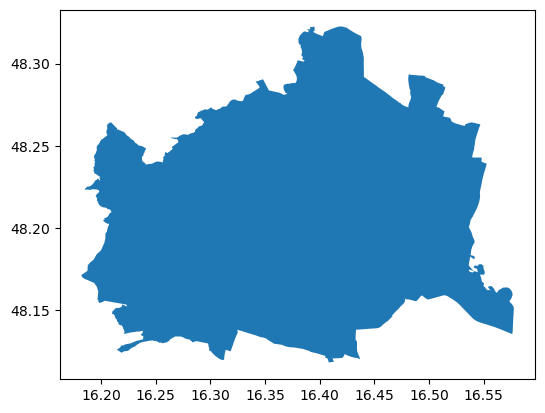

In [8]:
admin_city = ox.geocode_to_gdf('Vienna')
admin_city.plot()
plt.show()

**Blue spaces** are "Outdoor environments—natural or manmade—that prominently feature water, and are accessible and offer opportunities for recreation, relaxation, or aesthetic appreciation." (According to the World Health Organization (WHO) and related research (e.g., BlueHealth project))

This includes:
- Oceans and seas
- Rivers, lakes, ponds
- Canals, streams
- Urban fountains, reservoirs (if accessible)
- Wetlands (if part of nature/recreation areas)

They exclude:
- Wastewater facilities
- Industrial drainage systems
- Hidden/underground pipes
- Non-recreational, restricted areas (e.g. dams, treatment plants)


In [9]:
# Define the polygon for the administrative 
admin_poly = admin_city.geometry.values[0]


# Download POIs for blue spaces within the administrative boundary
tags_blue = {
    'natural': ['water', 'wetland'],
    'waterway': ['stream', 'river', 'canal'],
    'water': ['pond', 'lake', 'reservoir', 'basin', 'fishpond']
}
blue = ox.features_from_polygon(admin_poly, tags=tags_blue)

print("Water sources:", len(blue))
print("Type of data:", type(blue))
blue.head(3)

Water sources: 2207
Type of data: <class 'geopandas.geodataframe.GeoDataFrame'>


geometry  \
element  id                                                              
node     6813960988                          POINT (16.41034 48.13083)   
relation 75          POLYGON ((16.42474 48.22954, 16.42471 48.22955...   
         18443       POLYGON ((16.5844 48.1324, 16.58205 48.13265, ...   

                    river:waterway_distance waterway source  \
element  id                                                   
node     6813960988                     NaN      NaN    NaN   
relation 75                             NaN      NaN    NaN   
         18443                          NaN      NaN    NaN   

                                  name alt_name name:cs name:de name:es  \
element  id                                                               
node     6813960988                NaN      NaN     NaN     NaN     NaN   
relation 75          Untere Alte Donau      NaN     NaN     NaN     NaN   
         18443                     NaN      NaN     NaN     NaN     NaN   

                    name:sk  ... toilets:wheelchair memorial fence_type sport  \
element  id                  ...                                                
node     6813960988     NaN  ...                NaN      NaN        NaN   NaN   
relation 75             NaN  ...                NaN      NaN        NaN   NaN   
         18443          NaN  ...                NaN      NaN        NaN   NaN   

                    abandoned  lit odbl attraction name:sh species:wikidata  
element  id                                                                  
node     6813960988       NaN  NaN  NaN        NaN     NaN              NaN  
relation 75               NaN  NaN  NaN        NaN     NaN              NaN  
         18443            NaN  NaN  NaN        NaN     NaN              NaN  

[3 rows x 132 columns]

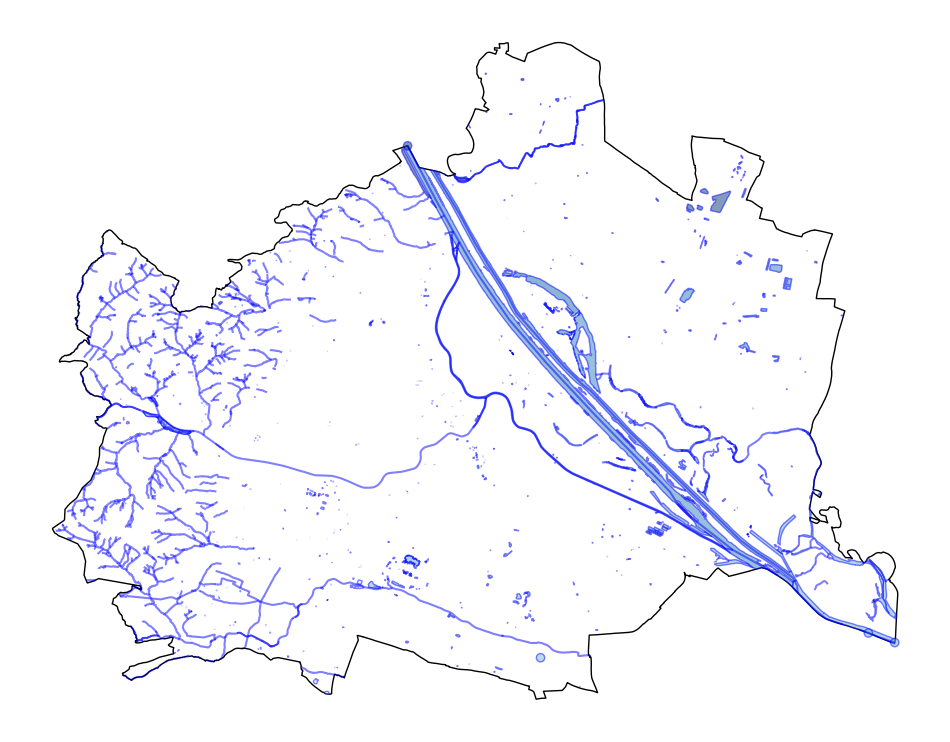

In [10]:
blue_clipped = gpd.clip(blue, admin_city)

# Create a plot to visualize the admin boundary and blue spaces
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
blue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()

### Further green space data
from OSM

In [10]:
'''
greens = ox.features_from_polygon(admin_poly, tags={'leisure': 'nature_reserve', 'leisure': 'garden', 'leisure': 'park', 'amenity': 'graveyard', 'landuse': 'cemetery', 'landuse': 'recreation_ground', 'landuse': 'forest'})

print("Green spaces:", len(greens))
print("Type of data:", type(greens))
greens.head()
'''

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


'\ngreens = ox.features_from_polygon(admin_poly, tags={\'leisure\': \'nature_reserve\', \'leisure\': \'garden\', \'leisure\': \'park\', \'amenity\': \'graveyard\', \'landuse\': \'cemetery\', \'landuse\': \'recreation_ground\', \'landuse\': \'forest\'})\n\nprint("Green spaces:", len(greens))\nprint("Type of data:", type(greens))\ngreens.head()\n'

In [11]:
'''
# Create a plot to visualize the admin boundary and green spaces
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
greens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')

# Customize the plot
ax.axis('off')
plt.show()
'''

"\n# Create a plot to visualize the admin boundary and green spaces\nf, ax = plt.subplots(1, 1, figsize=(12, 12))\n\n# Plot the administrative boundary\nadmin_city.plot(ax=ax, color='none', edgecolor='k')\n\n# Plot the parks\ngreens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')\n\n# Customize the plot\nax.axis('off')\nplt.show()\n"

In [12]:
'''
# both greens and blues by using OSM:
# to show the overlap of green and blue spaces in Vienna
f, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the parks
greens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')
blue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')

# Customize the plot
ax.axis('off')
plt.show()
'''

"\n# both greens and blues by using OSM:\n# to show the overlap of green and blue spaces in Vienna\nf, ax = plt.subplots(1, 1, figsize=(12, 12))\n\n# Plot the administrative boundary\nadmin_city.plot(ax=ax, color='none', edgecolor='k')\n\n# Plot the parks\ngreens.plot(ax=ax, cmap='Greens', alpha=0.5, edgecolor='darkgreen')\nblue_clipped.plot(ax=ax, cmap='Blues', alpha=0.5, edgecolor='blue')\n\n# Customize the plot\nax.axis('off')\nplt.show()\n"

## Visualizations

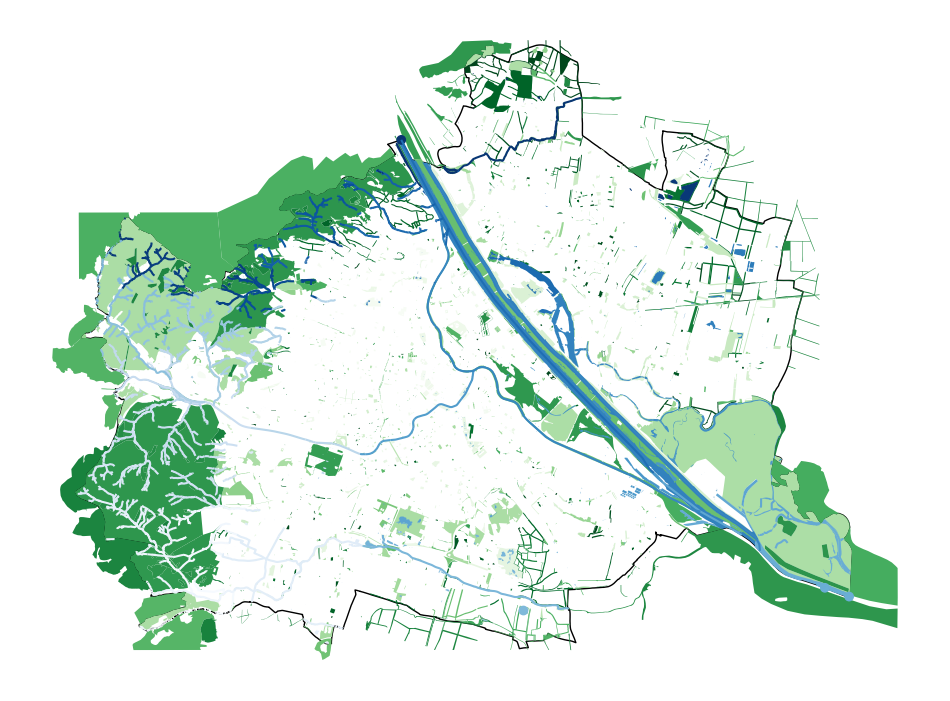

In [11]:
#greens from Open Data Austria, and blues from OSM:

f, ax = plt.subplots(1, 1, figsize=(12, 12))

admin_city.plot(ax=ax, color='none', edgecolor='k')
gdf_green.plot(ax=ax, cmap='Greens')
blue_clipped.plot(ax=ax, cmap='Blues')
ax.axis('off')

plt.savefig("output/vienna_green_blue_map.png", dpi=300, bbox_inches='tight')
plt.show()

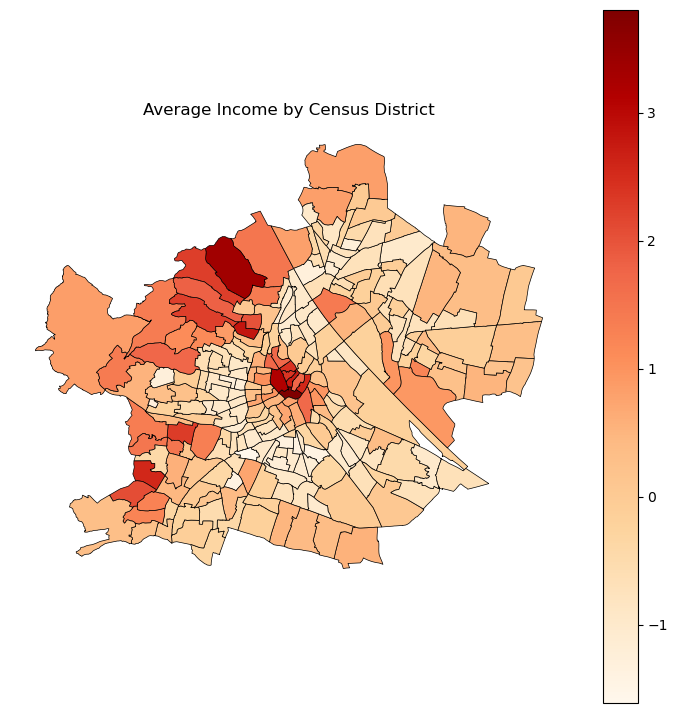

In [12]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='avg_income',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Average Income by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

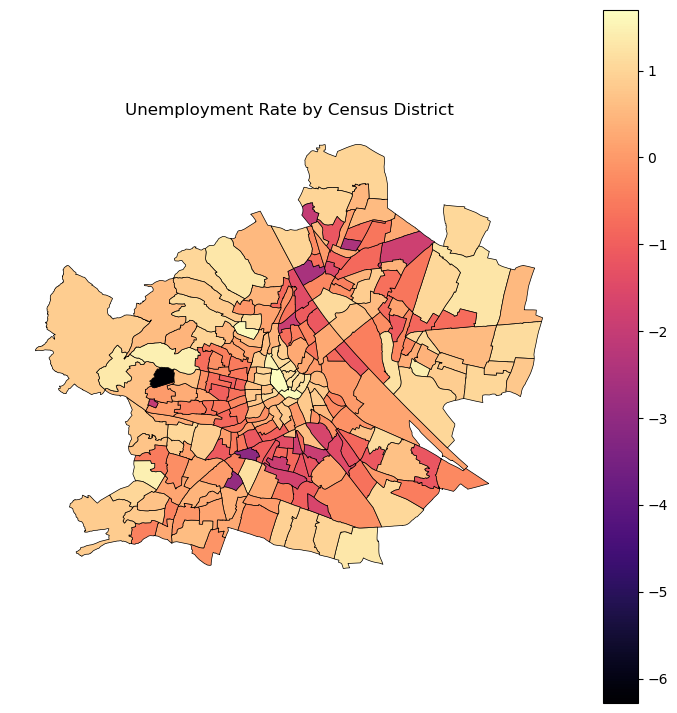

In [13]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='unemprate',      
    cmap='magma',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Unemployment Rate by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/unemp_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

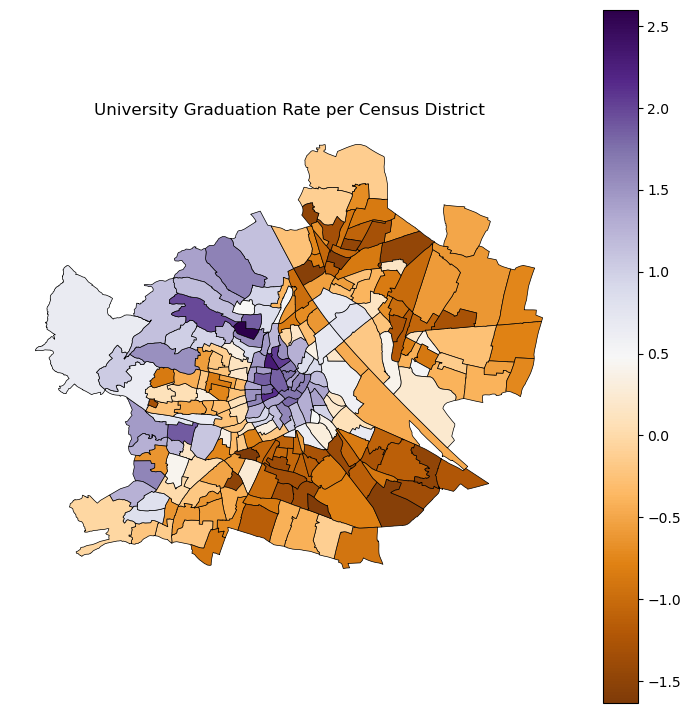

In [14]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='university_share',     
    cmap='PuOr',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,             
    ax=ax
)

ax.set_title("University Graduation Rate per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/uni_grad_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

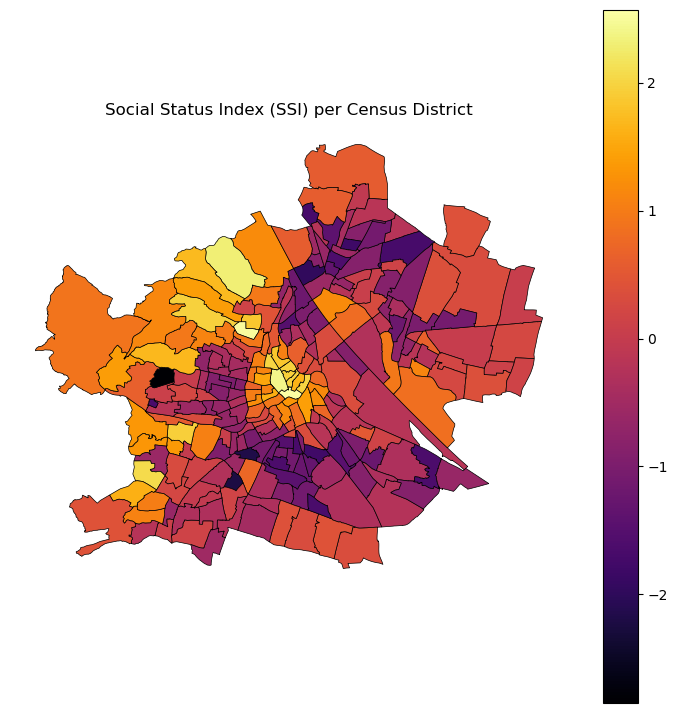

In [15]:
# Plot SSI by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='SSI',      
    cmap='inferno',              
    linewidth=0.5,           
    edgecolor='black',        
    legend=True,              
    ax=ax
)

ax.set_title("Social Status Index (SSI) per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
'''
# run 4 codes above as a loop instead of running several times

# Variables and settings to loop through
plot_settings = [
    {'column': 'SSI', 'title': 'Social Status Index (SSI)', 'cmap': 'inferno', 'file': 'ssi_map.png'},
    {'column': 'avg_income', 'title': 'Average Income', 'cmap': 'OrRd', 'file': 'avg_income_map.png'},
    {'column': 'university_share', 'title': 'University Graduate Share', 'cmap': 'Greens', 'file': 'university_share_map.png'},
    {'column': 'unemprate', 'title': 'Unemployment Rate', 'cmap': 'Blues', 'file': 'unemployment_map.png'},
]

for setting in plot_settings:
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Plot without built-in legend
    gdf_census.plot(
        column=setting['column'],
        cmap=setting['cmap'],
        linewidth=0.5,
        edgecolor='black',
        legend=False,
        ax=ax
    )

    # Custom colorbar
    norm = mpl.colors.Normalize(
        vmin=gdf_census[setting['column']].min(),
        vmax=gdf_census[setting['column']].max()
    )
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=setting['cmap'])
    sm._A = []
    
    cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.01)
    ax.set_title(f"{setting['title']} per Census District", fontsize=12)
    ax.axis('off')
    
    plt.savefig(setting['file'], dpi=300, bbox_inches='tight')
    plt.close()  # close the figure to free memory
'''

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


'\n# run 4 codes above as a loop instead of running several times\n\n# Variables and settings to loop through\nplot_settings = [\n    {\'column\': \'SSI\', \'title\': \'Social Status Index (SSI)\', \'cmap\': \'inferno\', \'file\': \'ssi_map.png\'},\n    {\'column\': \'avg_income\', \'title\': \'Average Income\', \'cmap\': \'OrRd\', \'file\': \'avg_income_map.png\'},\n    {\'column\': \'university_share\', \'title\': \'University Graduate Share\', \'cmap\': \'Greens\', \'file\': \'university_share_map.png\'},\n    {\'column\': \'unemprate\', \'title\': \'Unemployment Rate\', \'cmap\': \'Blues\', \'file\': \'unemployment_map.png\'},\n]\n\nfor setting in plot_settings:\n    fig, ax = plt.subplots(figsize=(9, 9))\n    \n    # Plot without built-in legend\n    gdf_census.plot(\n        column=setting[\'column\'],\n        cmap=setting[\'cmap\'],\n        linewidth=0.5,\n        edgecolor=\'black\',\n        legend=False,\n        ax=ax\n    )\n\n    # Custom colorbar\n    norm = mpl.colors.

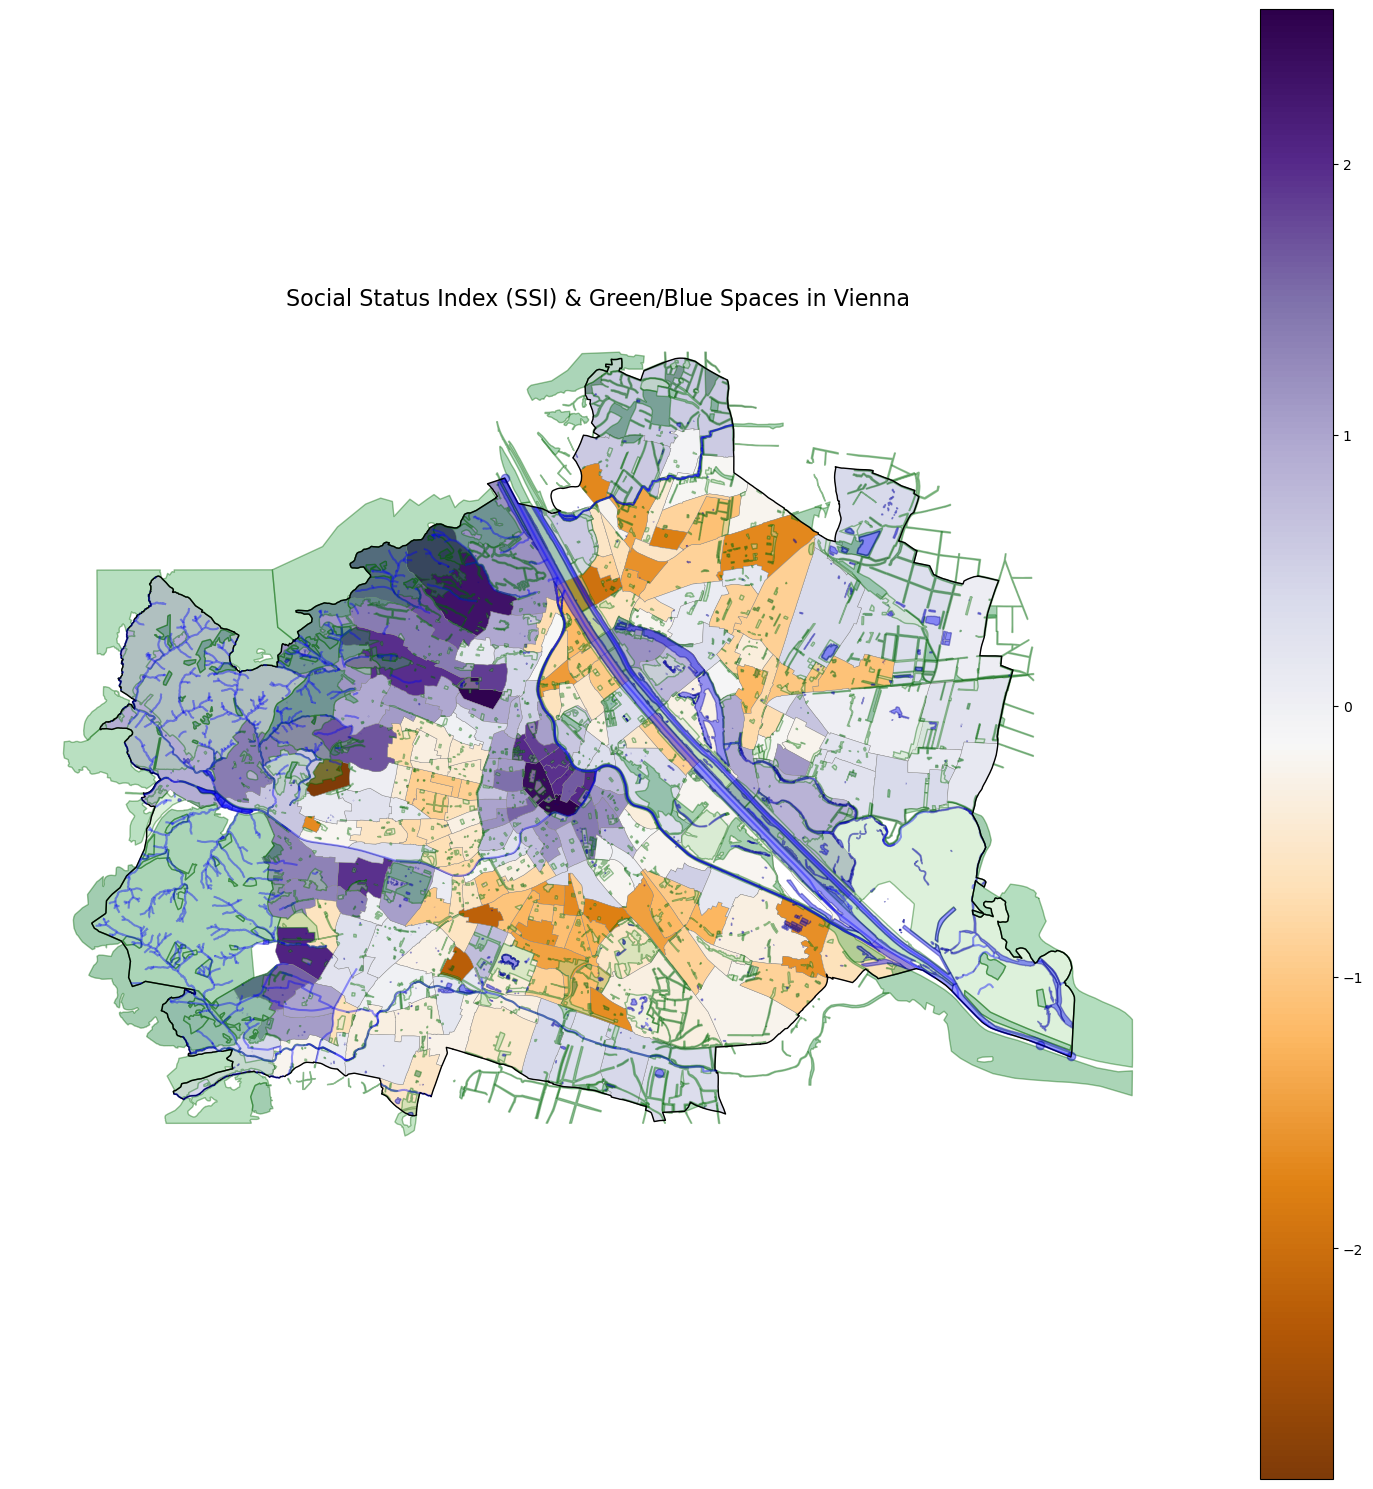

In [16]:
# Plot everything together
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot SSI as choropleth
gdf_census.plot(
    column='SSI',
    cmap='PuOr',     
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Overlay green and blue spaces
gdf_green.plot(ax=ax, cmap='Greens', alpha=0.4, edgecolor='darkgreen') #austrian governmental data
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue') #OSM data

# Optional: plot city border
admin_city.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# Tidy up
ax.set_title("Social Status Index (SSI) & Green/Blue Spaces in Vienna", fontsize=16)
ax.axis('off')

plt.tight_layout()

plt.savefig("output/ssi_ubgs_map.png", dpi=300, bbox_inches='tight')
plt.show()


## Correlation

* How much green/blue space overlap in each census district?
* Does the existence of green/blue spaces correlated with social status index (SSI)?

In [23]:
print(gdf_census.crs)
print(gdf_green.crs)
print(blue.crs)
#print(greens.crs)
print(admin_city.crs)

# epsg 4326 is coordinates, and not good for area and periphery calculations. 
# need to change their crs. Target crs: epsg=31256

gdf_census = gdf_census.to_crs(epsg=31256)
#greens = greens.to_crs(epsg=31256)
gdf_green = gdf_green.to_crs(epsg=31256)
admin_city = admin_city.to_crs(epsg=31256)
blue = blue.to_crs(epsg=31256)

EPSG:31256
EPSG:31256
EPSG:31256
EPSG:31256


In [24]:
print(gdf_green.geometry.type.unique())
print(blue.geometry.type.unique())

# in order to overlay, I need same types of geometries
# seperate blue geometries into 2 different gdf: blue_lines, blue_areas

# Separate blue space geometries by type
blue_areas = blue[blue.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
blue_lines = blue[blue.geometry.type.isin(['LineString', 'MultiLineString'])].copy()

print(blue_areas.geometry.type.unique())
print(blue_lines.geometry.type.unique())

['MultiPolygon' 'Polygon']
['Point' 'Polygon' 'MultiPolygon' 'LineString']
['Polygon' 'MultiPolygon']
['LineString']


In [25]:
# green areas per district
green_clipped = gpd.clip(gdf_green, admin_city)
green_in_census = gpd.overlay(gdf_census, green_clipped, how='intersection', keep_geom_type=False)
green_in_census['green_area'] = green_in_census.geometry.area
green_area_by_district = green_in_census.groupby('ZBEZ')['green_area'].sum().reset_index()

In [26]:
# blue areas per district
blue_area_in_census = gpd.overlay(gdf_census, blue_areas, how='intersection')
blue_area_in_census['blue_area'] = blue_area_in_census.geometry.area
blue_area_by_district = blue_area_in_census.groupby('ZBEZ')['blue_area'].sum().reset_index()

# blue length per district
blue_lines_in_census = gpd.overlay(gdf_census, blue_lines, how='intersection', keep_geom_type=False)
blue_lines_in_census['blue_length'] = blue_lines_in_census.geometry.length
blue_length_by_district = blue_lines_in_census.groupby('ZBEZ')['blue_length'].sum().reset_index()

In [27]:
# Merge green and blue components into census dataframe
gdf_census = gdf_census.merge(green_area_by_district, on='ZBEZ', how='left')
gdf_census = gdf_census.merge(blue_area_by_district, on='ZBEZ', how='left')
gdf_census = gdf_census.merge(blue_length_by_district, on='ZBEZ', how='left')

# Fill missing values (e.g., no green/blue areas or rivers) with 0
gdf_census[['green_area', 'blue_area', 'blue_length']] = gdf_census[[
    'green_area', 'blue_area', 'blue_length']].fillna(0)

gdf_census.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,district_area_km2,green_area,blue_area,blue_length
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",0.377557,1176.751740,16.971625,0.000000
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",0.379377,77668.038665,34107.715249,1181.722444
2,0103,1.706598,3.805033,1.641029,1.232519,2.570582,5,"POLYGON ((2735.149 340257.116, 2743.919 340257...",0.465497,25070.979682,135.225705,1090.379031


In [28]:
# Calculate district area in square kilometers (since CRS is in meters)
gdf_census['district_area_km2'] = gdf_census.geometry.area / 1e6

# Normalize each variable by district size
gdf_census['green_ratio'] = gdf_census['green_area'] / gdf_census['district_area_km2']
gdf_census['blue_area_ratio'] = gdf_census['blue_area'] / gdf_census['district_area_km2']
gdf_census['blue_length_km'] = gdf_census['blue_length'] / 1000  # optional, km of river

In [29]:
#COMMENT FOR FUTURE: DO IT BY EXCLUDING INNERE STADT. IT HAS HIGH SSI, BUT HISTROICAL BUILDINGS LESS UBGS
# Correlation matrix
corr_matrix = gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']].corr()
print(corr_matrix)

                      SSI  green_ratio  blue_area_ratio  blue_length_km
SSI              1.000000     0.204862        -0.053523        0.163702
green_ratio      0.204862     1.000000         0.308180        0.638585
blue_area_ratio -0.053523     0.308180         1.000000        0.138026
blue_length_km   0.163702     0.638585         0.138026        1.000000


In [27]:
'''
# to visualize correlations in scatter plots
import seaborn as sns

sns.pairplot(gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']])
plt.show()
'''

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


"\n# to visualize correlations in scatter plots\nimport seaborn as sns\n\nsns.pairplot(gdf_census[['SSI', 'green_ratio', 'blue_area_ratio', 'blue_length_km']])\nplt.show()\n"

In [30]:
import statsmodels.api as sm

# Prepare data
X = gdf_census[['university_share', 'avg_income', 'unemprate', 'benefit_share', 'green_ratio', 'blue_area_ratio', 'blue_length_km']]
X = sm.add_constant(X)  # adds intercept term
A = gdf_census[['university_share', 'avg_income', 'unemprate', 'benefit_share']]
A = sm.add_constant(A)  # adds intercept term
B = gdf_census[['green_ratio', 'blue_area_ratio', 'blue_length_km']]
B = sm.add_constant(B)  # adds intercept term
y = gdf_census['SSI']

# Fit model
model = sm.OLS(y, X).fit()
model2 =sm.OLS(y, A).fit()
model3 =sm.OLS(y, B).fit()
print(model.summary())
print(model2.summary())
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    SSI   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.745e+23
Date:                Wed, 16 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:25:17   Log-Likelihood:                 5855.9
No. Observations:                 246   AIC:                        -1.170e+04
Df Residuals:                     238   BIC:                        -1.167e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6.908e-12   9.68e-13  

In [32]:
# Prepare data
X = gdf_census['SSI']
X = sm.add_constant(X)  # adds intercept term
y = gdf_census[['green_ratio']]

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            green_ratio   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     10.69
Date:                Wed, 16 Apr 2025   Prob (F-statistic):            0.00123
Time:                        14:25:57   Log-Likelihood:                -3260.6
No. Observations:                 246   AIC:                             6525.
Df Residuals:                     244   BIC:                             6532.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.088e+05   8839.373     12.307      0.0

## Introduction of housing data into the analysis

* Data is from Statistiks Austria. 
* Does the existence of green/blue spaces affect the housing prices in that district?
* If they affect, can we check how it changes with proximity of housing to green/blue space?

In [33]:
# !pip install odfpy pandas
# Load ODS file and list all sheet names
housing_path = "data/SpecialEvaluation.ods" 
housing_data = pd.read_excel(housing_path, engine="odf", sheet_name=None)

# Show available sheets
print(housing_data.keys())

dict_keys(['Apartment_Prices', 'House_Prices', 'Building_Plots', 'Federal_Provinces', 'Apartment_Prices_municipalities', 'House_Prices_municipalities', 'Fed__states_and_constr__Periods'])


In [34]:
housing_data = pd.read_excel(
    housing_path,
    engine="odf",
    sheet_name="Apartment_Prices",  
    header=1                        # use row 2 as column names
)
housing_data.columns

Index(['D. CD.', 'Districts', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023],
      dtype='object')

In [35]:
# Keep only Vienna rows
housing_vienna = housing_data[
    housing_data['Districts'].str.contains('Wien', na=False) &
    ~housing_data['Districts'].str.contains('Wiener Neustadt', na=False)
]
housing_vienna.columns = housing_vienna.columns.astype(str)

housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()
housing_vienna

/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_20196/1985756449.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_vienna.loc[:, 'district_clean'] = housing_vienna['Districts'].str.split(',').str[1].str.strip()


,D. CD.,Districts,2015,2016,2017,2018,2019,2020,2021,2022,2023,district_clean
93,901,"Wien 1.,Innere Stadt",6569,7861,9368,10955,11186,10947,13078,14389,12733,Innere Stadt
94,902,"Wien 2.,Leopoldstadt",3650,4125,4327,4482,4590,5215,5331,6181,5494,Leopoldstadt
95,903,"Wien 3.,Landstraße",3934,4039,4483,4787,4375,5483,5715,5850,5635,Landstraße
96,904,"Wien 4.,Wieden",4189,4237,4932,5195,5650,5586,6471,7776,6646,Wieden
97,905,"Wien 5.,Margareten",3272,3500,3548,3662,3796,4634,5648,5440,4562,Margareten
98,906,"Wien 6.,Mariahilf",4147,4349,4089,4124,4836,5208,5696,5822,5325,Mariahilf
99,907,"Wien 7.,Neubau",4774,4553,4755,5405,5833,6043,6332,6336,5929,Neubau
100,908,"Wien 8.,Josefstadt",4020,4744,5292,4975,4798,5996,7842,7697,6148,Josefstadt
101,909,"Wien 9.,Alsergrund",4106,4132,4942,5215,5250,5321,5734,6234,6017,Alsergrund
102,910,"Wien 10.,Favoriten",2436,3331,3191,3942,3913,3571,3567,4211,3796,Favoriten


In [36]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2
districts

,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,STATAUSTR0,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,91301.0,3.771397e+07,29668.16,2023-07-18,13126.0,"POLYGON ((16.21423 48.20652, 16.21425 48.20651..."
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,91501.0,3.916953e+06,9711.71,2023-07-18,13127.0,"POLYGON ((16.32732 48.205, 16.33366 48.20406, ..."
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,90701.0,1.608248e+06,5312.54,2023-07-18,13128.0,"POLYGON ((16.33873 48.20854, 16.33901 48.20849..."
3,Landstraße,3.0,III,"3., Landstraße",III. Landstraße,LANDSTRASSE,III.,03,1030.0,903.0,90301.0,7.403038e+06,13961.80,2023-07-18,13129.0,"POLYGON ((16.39662 48.20739, 16.39678 48.20656..."
4,Josefstadt,8.0,VIII,"8., Josefstadt",VIII. Josefstadt,JOSEFSTADT,VIII.,08,1080.0,908.0,90801.0,1.089946e+06,4170.30,2023-07-18,13130.0,"POLYGON ((16.34915 48.21516, 16.35099 48.21497..."
5,Innere Stadt,1.0,I,"1., Innere Stadt",I. Innere Stadt,INNERE STADT,I.,01,1010.0,901.0,90101.0,2.868774e+06,6972.75,2023-07-18,13131.0,"POLYGON ((16.37264 48.21662, 16.37314 48.21621..."
6,Ottakring,16.0,XVI,"16., Ottakring",XVI. Ottakring,OTTAKRING,XVI.,16,1160.0,916.0,91601.0,8.673047e+06,18371.12,2023-07-18,13132.0,"POLYGON ((16.27621 48.22704, 16.27646 48.22678..."
7,Alsergrund,9.0,IX,"9., Alsergrund",IX. Alsergrund,ALSERGRUND,IX.,09,1090.0,909.0,90901.0,2.967385e+06,7919.54,2023-07-18,13133.0,"POLYGON ((16.36165 48.23192, 16.36166 48.2319,..."
8,Leopoldstadt,2.0,II,"2., Leopoldstadt",II. Leopoldstadt,LEOPOLDSTADT,II.,02,1020.0,902.0,90201.0,1.924200e+07,27093.08,2023-07-18,13134.0,"POLYGON ((16.40345 48.23192, 16.40503 48.23067..."
9,Währing,18.0,XVIII,"18., Währing",XVIII. Währing,WÄHRING,XVIII.,18,1180.0,918.0,91801.0,6.347205e+06,18058.47,2023-07-18,13135.0,"POLYGON ((16.29502 48.24961, 16.29508 48.2496,..."


In [37]:
# Merging housing prices data into districts GeoDataFrame
housing_districts = districts.merge(
    housing_vienna[['district_clean', '2015', '2016', '2017', '2018', '2019', '2020',  '2021', '2022', '2023']],
    left_on='NAMEK',
    right_on='district_clean',
    how='left'
)

In [40]:
housing_districts.columns 

Index(['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL',
       'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'FLAECHE', 'UMFANG',
       'AKT_TIMEST', 'SE_SDO_ROW', 'geometry', 'district_clean', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype='object')

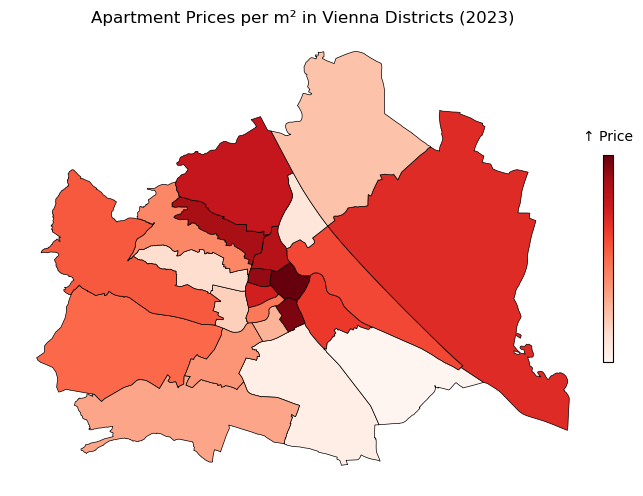

In [41]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot without legend
housing_districts_plot = housing_districts.plot(
    column='2023',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False 
)

# Create a scalar mappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=housing_districts['2023'].min(),
    vmax=housing_districts['2023'].max()
)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm._A = []  # required for matplotlib <3.1

# Adding the colorbar manually
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.3,              
    pad=0.01,                
    orientation='vertical',
    location='right'         
)

# Remove ticks and add title to the colorbar
cbar.ax.set_yticks([])
cbar.ax.set_title('↑ Price', fontsize=10, pad=10)

# Final plot tweaks
ax.set_title("Apartment Prices per m² in Vienna Districts (2023)", fontsize=12)
ax.axis('off')
plt.show()

In [42]:
green_clipped = green_clipped.to_crs(districts.crs)
blue_clipped = blue_clipped.to_crs(districts.crs)

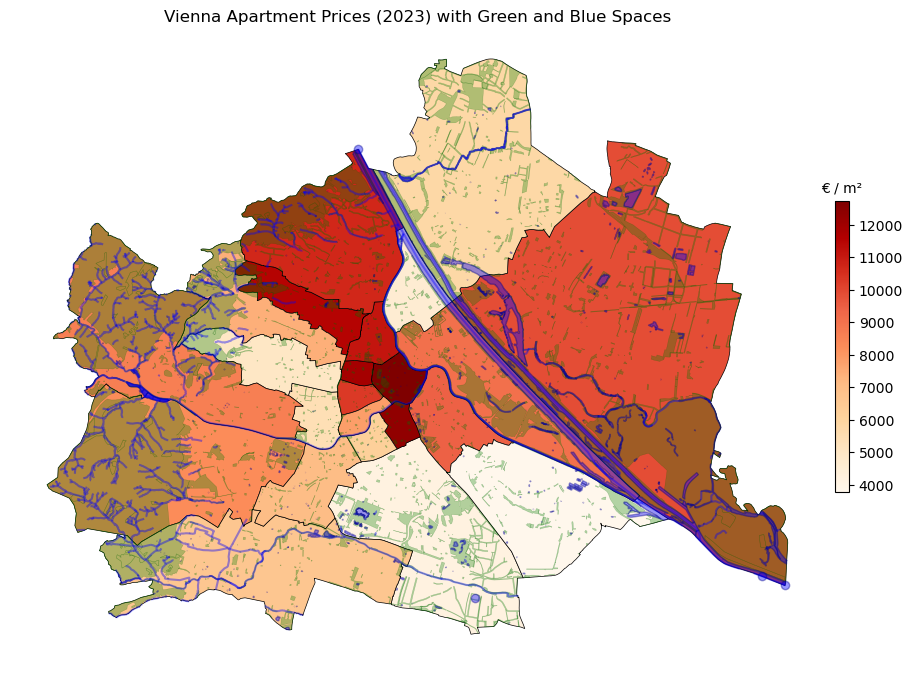

In [43]:
# Setup plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot housing prices as base choropleth
housing_districts.plot(
    column='2023',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False  
)

# Overlay green and blue spaces
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Add colorbar manually
norm = mpl.colors.Normalize(vmin=housing_districts['2023'].min(), vmax=housing_districts['2023'].max())
sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.01)
cbar.ax.set_title('€ / m²', fontsize=10)

# Title & layout
ax.set_title("Vienna Apartment Prices (2023) with Green and Blue Spaces", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()


## Correlation of housing prices with UBGS

* Is there a correlation between the amount of green/blue spaces in districts and their average housing price per m2?

In [44]:
print(gdf_census.crs)
print(housing_districts.crs)

EPSG:31256
EPSG:4326


In [45]:
housing_districts = housing_districts.to_crs(gdf_census.crs)
print(housing_districts.crs)

EPSG:31256


In [54]:
census_with_district = gpd.sjoin(
    gdf_census,
    housing_districts[['district_clean', 'geometry']],  # keep only name + geometry of Bezirke
    how='left',
    predicate='intersects'
)

In [55]:
census_with_district.head(3)

,ZBEZ,university_share,avg_income,unemprate,benefit_share,SSI,quintile,geometry,district_area_km2,green_area,blue_area,blue_length,green_ratio,blue_area_ratio,blue_length_km,index_right,district_clean
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",0.377557,1176.751740,16.971625,0.000000,3116.750799,44.951134,0.000000,8,Leopoldstadt
0,0101,1.604954,1.741399,1.125923,1.123008,1.653992,5,"POLYGON ((3485.019 341498.126, 3484.459 341498...",0.377557,1176.751740,16.971625,0.000000,3116.750799,44.951134,0.000000,5,Innere Stadt
1,0102,1.653812,2.565233,1.237000,1.139440,2.000434,5,"POLYGON ((3487.789 341009.066, 3470.019 341017...",0.379377,77668.038665,34107.715249,1181.722444,204725.351202,89904.600437,1.181722,3,Landstraße


In [56]:
# Aggregate total green/blue values per main district
green_blue_summary = census_with_district.groupby('district_clean')[
    ['green_ratio', 'blue_area_ratio', 'blue_length_km']
].sum().reset_index()

In [60]:
# Merge green/blue summary into housing districts
districts_full = housing_districts.merge(
    green_blue_summary,
    on='district_clean',
    how='left'
)

print(districts_full.columns)
districts_full.head(3)

Index(['NAMEK', 'BEZNR', 'BEZ_RZ', 'NAMEK_NUM', 'NAMEK_RZ', 'NAMEG', 'LABEL',
       'BEZ', 'DISTRICT_C', 'STATAUSTRI', 'STATAUSTR0', 'FLAECHE', 'UMFANG',
       'AKT_TIMEST', 'SE_SDO_ROW', 'geometry', 'district_clean', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       'green_ratio', 'blue_area_ratio', 'blue_length_km'],
      dtype='object')


,NAMEK,BEZNR,BEZ_RZ,NAMEK_NUM,NAMEK_RZ,NAMEG,LABEL,BEZ,DISTRICT_C,STATAUSTRI,...,2017,2018,2019,2020,2021,2022,2023,green_ratio,blue_area_ratio,blue_length_km
0,Hietzing,13.0,XIII,"13., Hietzing",XIII. Hietzing,HIETZING,XIII.,13,1130.0,913.0,...,4043,4423,4462,4821,5593,6159,5327,3.993495e+06,37268.759074,97.913336
1,Rudolfsheim-Fünfhaus,15.0,XV,"15., Rudolfsheim-Fünfhaus",XV. Rudolfsheim-Fünfhaus,RUDOLFSHEIM-FÜNFHAUS,XV.,15,1150.0,915.0,...,3315,3827,3860,4111,4729,4460,4215,8.704137e+05,658.385414,5.912850
2,Neubau,7.0,VII,"7., Neubau",VII. Neubau,NEUBAU,VII.,07,1070.0,907.0,...,4755,5405,5833,6043,6332,6336,5929,8.574807e+05,1802.907165,2.143164


In [61]:
# Correlation matrix
districts_full[['2023', 'green_ratio', 'blue_area_ratio', 'blue_length_km']].corr()

,2023,green_ratio,blue_area_ratio,blue_length_km
2023,1.000000,-0.147541,-0.105585,-0.121767
green_ratio,-0.147541,1.000000,0.602164,0.668834
blue_area_ratio,-0.105585,0.602164,1.000000,0.056649
blue_length_km,-0.121767,0.668834,0.056649,1.000000


In [63]:
import statsmodels.api as sm

ubgs = districts_full[['green_ratio', 'blue_area_ratio', 'blue_length_km']]
ubgs = sm.add_constant(ubgs)  
price = districts_full['2023']

model = sm.OLS(price, ubgs).fit()
print(model.summary())


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [64]:
print(ubgs.dtypes)

const              float64
green_ratio        float64
blue_area_ratio    float64
blue_length_km     float64
dtype: object


In [66]:
# Convert all columns to numeric (force errors to NaN)
ubgs = ubgs.apply(pd.to_numeric, errors='coerce')
price = pd.to_numeric(price, errors='coerce')

print(ubgs.isna().sum())   # NaNs in predictors
print(price.isna().sum())  # NaNs in outcome variable

const              0
green_ratio        0
blue_area_ratio    0
blue_length_km     0
dtype: int64
0


In [68]:
model = sm.OLS(price, ubgs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   2023   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.129
Method:                 Least Squares   F-statistic:                    0.1627
Date:                Wed, 16 Apr 2025   Prob (F-statistic):              0.920
Time:                        14:53:21   Log-Likelihood:                -204.08
No. Observations:                  23   AIC:                             416.2
Df Residuals:                      19   BIC:                             420.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5840.7097    937.749     

# WHO theory

In [39]:
# all residential buildings
residential_tags = {'building': ['residential', 'apartments', 'house', 'detached', 'terrace']}
residential = ox.features_from_place('Vienna, Austria', tags=residential_tags)

print("Number of residential buildings:", len(residential))
residential.head()

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Number of residential buildings: 66085


entrance                   geometry addr:unit  \
element_type osmid                                                      
node         3050128807      NaN  POINT (16.45262 48.24040)       NaN   
             3191378969      NaN  POINT (16.28469 48.18459)       NaN   
             3191378970      NaN  POINT (16.28475 48.18473)       NaN   
             3220013168      NaN  POINT (16.47623 48.21350)       NaN   
             3220013171      NaN  POINT (16.47638 48.21381)       NaN   

                        addr:city addr:country addr:housenumber addr:postcode  \
element_type osmid                                                              
node         3050128807      Wien           AT              NaN          1220   
             3191378969      Wien           AT               39          1130   
             3191378970      Wien           AT               41          1130   
             3220013168      Wien           AT              7/5          1220   
             3220013171      Wien           AT              7/1          1220   

                                addr:street amenity created_by  ... community  \
element_type osmid                                              ...             
node         3050128807       Pogrelzstraße     NaN        NaN  ...       NaN   
             3191378969  Münichreiterstraße     NaN        NaN  ...       NaN   
             3191378970  Münichreiterstraße     NaN        NaN  ...       NaN   
             3220013168      Stavangergasse     NaN        NaN  ...       NaN   
             3220013171      Stavangergasse     NaN        NaN  ...       NaN   

                        community:de community:en community:fr  \
element_type osmid                                               
node         3050128807          NaN          NaN          NaN   
             3191378969          NaN          NaN          NaN   
             3191378970          NaN          NaN          NaN   
             3220013168          NaN          NaN          NaN   
             3220013171          NaN          NaN          NaN   

                        community:gender community:it roof:type former:name  \
element_type osmid                                                            
node         3050128807              NaN          NaN       NaN         NaN   
             3191378969              NaN          NaN       NaN         NaN   
             3191378970              NaN          NaN       NaN         NaN   
             3220013168              NaN          NaN       NaN         NaN   
             3220013171              NaN          NaN       NaN         NaN   

                        building:height addr:interpolation  
element_type osmid                                          
node         3050128807             NaN                NaN  
             3191378969             NaN                NaN  
             3191378970             NaN                NaN  
             3220013168             NaN                NaN  
             3220013171             NaN                NaN  

[5 rows x 252 columns]

In [40]:
# City-wide Vienna boundary from districts
vienna_boundary = districts.unary_union
vienna_gdf = gpd.GeoDataFrame(geometry=[vienna_boundary], crs=districts.crs)

# Clean geometry and reproject everything to a common projected CRS (EPSG:31256)
residential = residential[residential.is_valid & ~residential.is_empty]
gdf_green = gdf_green[gdf_green.is_valid & ~gdf_green.is_empty]

crs_proj = 31256
vienna_gdf_proj = vienna_gdf.to_crs(epsg=crs_proj)
residential_proj = residential.to_crs(epsg=crs_proj)
green_proj = gdf_green.to_crs(epsg=crs_proj)

# Clip residential and green areas to Vienna boundary
residential_vienna = gpd.clip(residential_proj, vienna_gdf_proj)
green_vienna = gpd.clip(green_proj, vienna_gdf_proj)

# Calculate centroids of residential buildings
res_centroids = residential_vienna.copy()
res_centroids['geometry'] = res_centroids.centroid

# Calculate distances to nearest green space
green_union = unary_union(green_vienna.geometry)
res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

# Output stats
total = len(res_centroids)
within = res_centroids['within_300m'].sum()
percent = (within / total) * 100 if total > 0 else 0

print("WHO 300m Rule for Vienna:")
print(f"Total residential buildings: {total}")
print(f"Within 300m of green space: {within}")
print(f"Percentage compliant with WHO guideline: {percent:.2f}%")

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


WHO 300m Rule for Vienna:
Total residential buildings: 66085
Within 300m of green space: 62173
Percentage compliant with WHO guideline: 94.08%


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


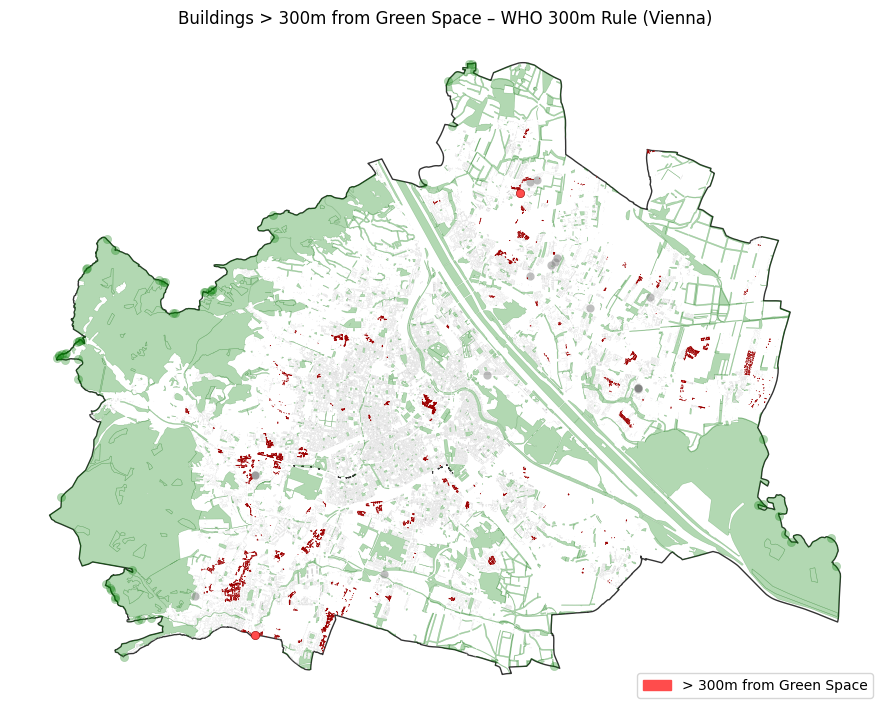

In [41]:
# import matplotlib.patches as mpatches

# Clip green areas to Vienna for clean plot
green_clipped = gpd.clip(green_proj, vienna_gdf_proj)

# Get non-compliant buildings
non_compliant_buildings = residential_vienna[~res_centroids['within_300m'].values]

# Create the plot
fig, ax = plt.subplots(figsize=(9, 9))

# Plot layers
vienna_gdf_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)  # Green areas
residential_vienna.plot(ax=ax, color='grey', alpha=0.5, edgecolor='white', linewidth=0.2) # Residential buildings
non_compliant_buildings.plot(ax=ax, color='#FF4C4C', edgecolor='#990000', linewidth=0.4)  # Non-compliant

# Legend
legend_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
plt.legend(handles=[legend_patch], loc='lower right')

# Title and export
plt.title("Buildings > 300m from Green Space – WHO 300m Rule (Vienna)", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/vienna_who_300m_noncompliant_only_legend.png", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
def split_poly_to_hexagons(admin_gdf, resolution, crs):
    
    coords = list(admin_gdf.geometry.to_list()[0].exterior.coords)
    admin_geojson = {"type": "Polygon",  "coordinates": [coords]}
    hexagons = h3.polyfill(admin_geojson, 
                           resolution, 
                           geo_json_conformant=True)
    
    hexagon_geometries = {hex_id: Polygon(h3.h3_to_geo_boundary(hex_id, \
                                geo_json=True)) for hex_id in hexagons}
    gdf_hexagon_geometries = gpd.GeoDataFrame(hexagon_geometries.items(), 
                                    columns=['hex_id', 'geometry'])
    gdf_hexagon_geometries.crs = crs
    
    return gdf_hexagon_geometries

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


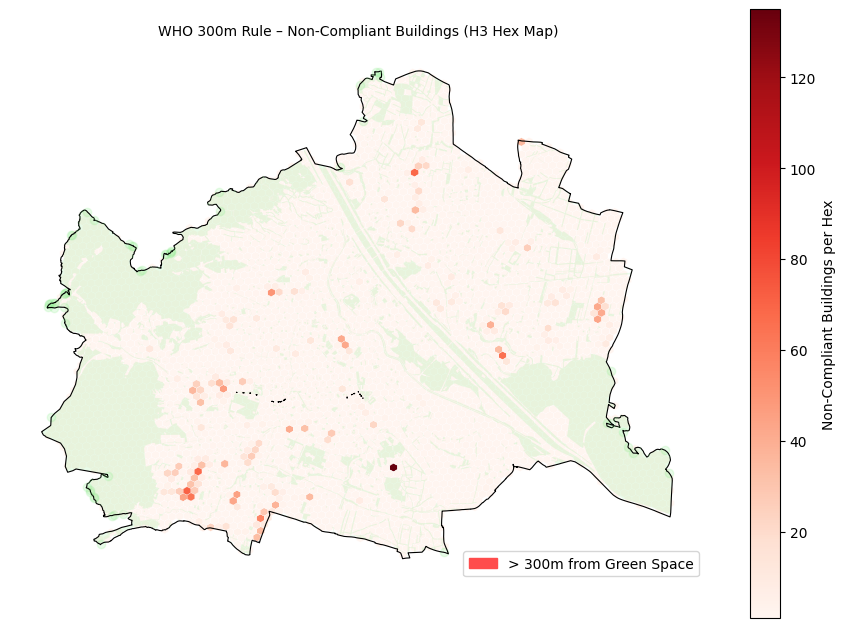

In [43]:
# Generate H3 hexagons for Vienna
vienna_proj = vienna_gdf.to_crs(epsg=4326)
hex_gdf = split_poly_to_hexagons(vienna_proj, resolution=9, crs="EPSG:4326")

# Reproject hexes and non-compliant buildings
hex_gdf_proj = hex_gdf.to_crs(epsg=31256)
noncompliant_proj = residential_vienna[~res_centroids['within_300m'].values]
noncompliant_proj = noncompliant_proj.to_crs(epsg=31256)

# Spatial join – assign buildings to H3 hexagons
join_hex = gpd.sjoin(hex_gdf_proj, noncompliant_proj, how="left", predicate="contains")

# Count buildings per hex
counts = join_hex.groupby('hex_id').size()
hex_gdf_proj['noncompliant_count'] = hex_gdf_proj['hex_id'].map(counts).fillna(0)

fig, ax = plt.subplots(figsize=(9, 9))
hex_gdf_proj.plot(
    ax=ax,
    column='noncompliant_count',
    cmap='Reds',
    edgecolor='white',
    linewidth=0.2,
    legend=True,
    legend_kwds={'label': 'Non-Compliant Buildings per Hex', 'shrink': 0.7}
)
green_clipped = gpd.clip(green_proj, vienna_gdf_proj)
green_clipped.plot(ax=ax, color='#90EE90', alpha=0.2)
vienna_gdf_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)

red_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
plt.legend(handles=[red_patch], loc='lower right')

plt.title('WHO 300m Rule – Non-Compliant Buildings (H3 Hex Map)', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.savefig('output/vienna_noncompliant_h3_hexmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Spatial join to assign each building to its district
districts_proj = districts.to_crs(epsg=31256)
res_with_district = gpd.sjoin(res_centroids, districts_proj[['NAMEK', 'geometry']], how='left', predicate='within')

# Group by district and summarize WHO compliance
district_summary = (
    res_with_district
    .groupby('NAMEK')
    .agg(
        total_buildings=('within_300m', 'count'),
        compliant_buildings=('within_300m', 'sum')
    )
    .assign(percent_compliant=lambda df: 100 * df['compliant_buildings'] / df['total_buildings'])
    .sort_values(by='percent_compliant', ascending=False)
)


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Citywide non-compliance rate: 5.92%


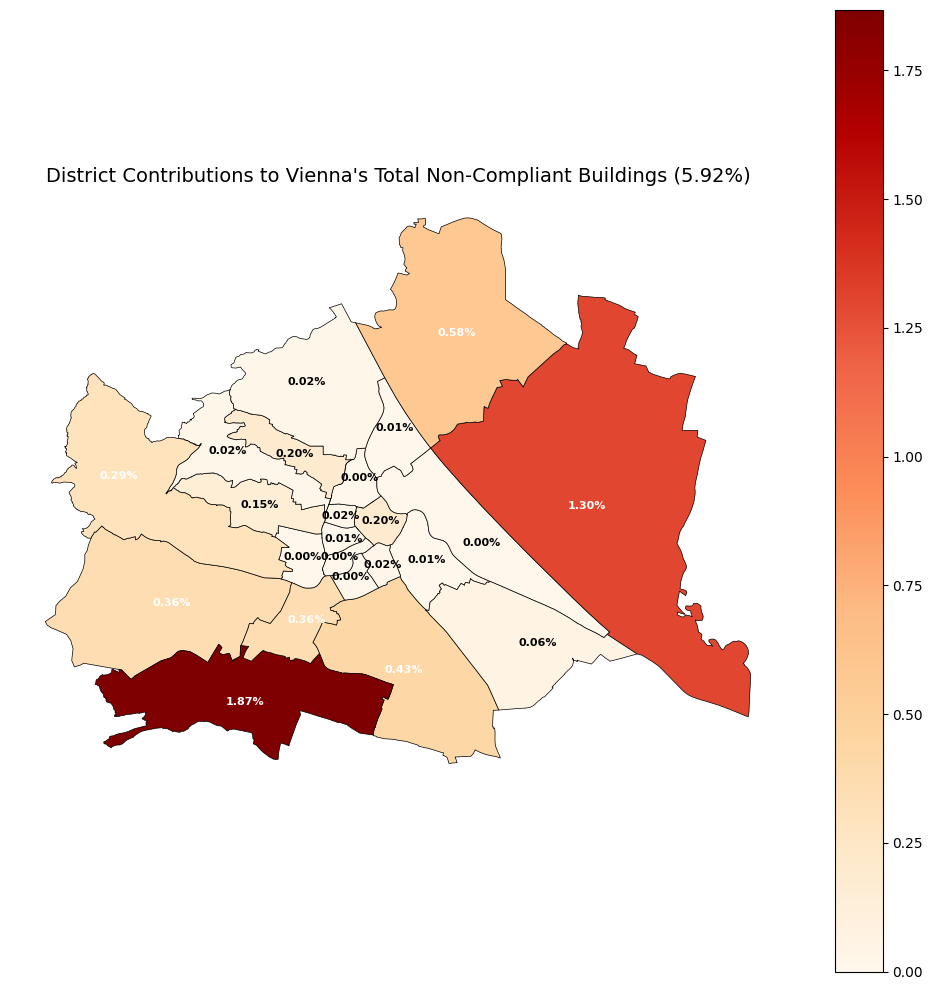

In [45]:
# Reset and calculate district-level non-compliance
district_summary = district_summary.reset_index()
district_summary['noncompliant_buildings'] = (
    district_summary['total_buildings'] - district_summary['compliant_buildings']
)

# Calculate citywide non-compliance percent
citywide_total = district_summary['total_buildings'].sum()
citywide_compliant = district_summary['compliant_buildings'].sum()
citywide_noncompliant = citywide_total - citywide_compliant
citywide_noncompliance_percent = (citywide_noncompliant / citywide_total) * 100
print(f"Citywide non-compliance rate: {citywide_noncompliance_percent:.2f}%")

# Scale district values to match citywide % total
district_summary['noncompliant_share_scaled'] = (
    district_summary['noncompliant_buildings'] / citywide_noncompliant * citywide_noncompliance_percent
)

# Merge with spatial data
districts_cityshare = districts.merge(
    district_summary[['NAMEK', 'noncompliant_share_scaled']], on='NAMEK'
)
districts_cityshare = districts_cityshare.to_crs(epsg=31256)


fig, ax = plt.subplots(figsize=(10, 10))
districts_cityshare.plot(
    ax=ax,
    column='noncompliant_share_scaled',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

districts_cityshare['label_point'] = districts_cityshare.representative_point()
for _, row in districts_cityshare.iterrows():
    ax.text(
        row['label_point'].x,
        row['label_point'].y,
        f"{row['noncompliant_share_scaled']:.2f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['noncompliant_share_scaled'] < 0.2 else 'white',
        weight='bold'
    )

plt.title(f"District Contributions to Vienna's Total Non-Compliant Buildings ({citywide_noncompliance_percent:.2f}%)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig("output/vienna_noncompliance_contribution_scaled_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [46]:
# Calculate non-compliance % within each district
district_summary['percent_noncompliant'] = 100 - district_summary['percent_compliant']
district_summary = district_summary.reset_index()  # Make NAMEK a column

c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


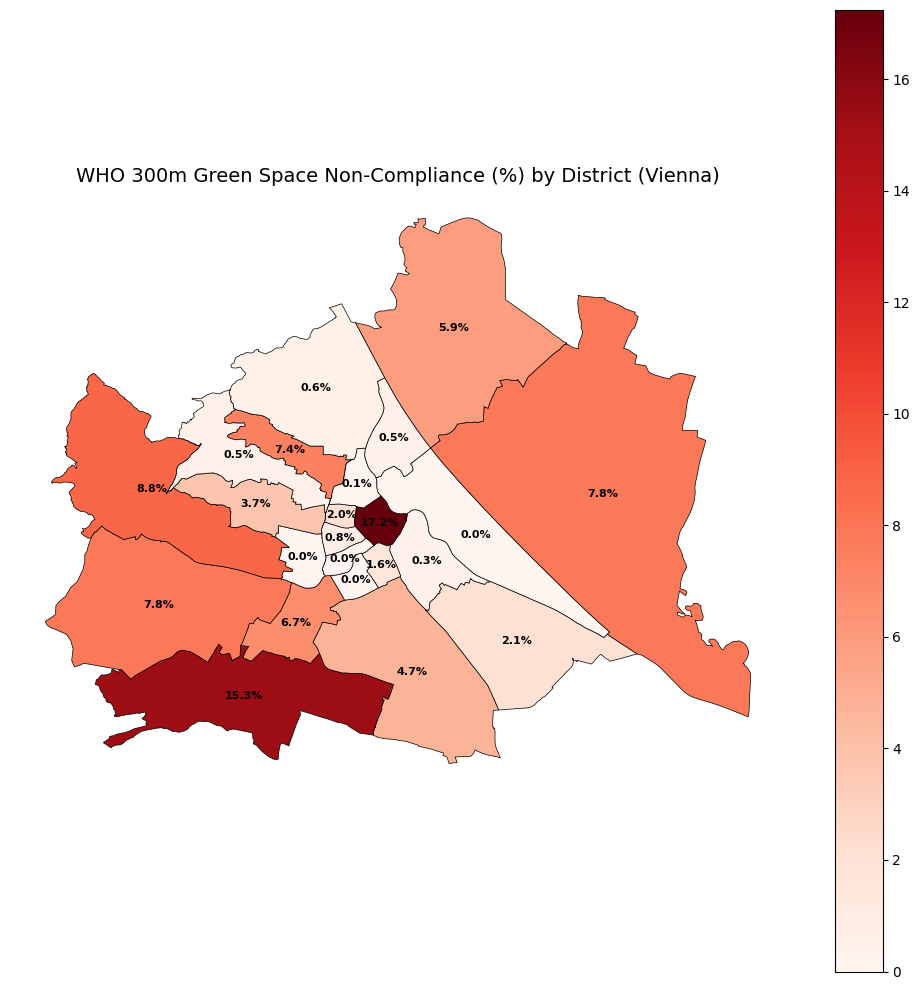

In [47]:
# Merge with districts GeoDataFrame
districts_plot = districts.merge(district_summary, on='NAMEK')
districts_plot = districts_plot.to_crs(epsg=31256)

# Get label positions (centroids)
districts_plot['centroid'] = districts_plot.geometry.centroid
districts_plot['label_x'] = districts_plot.centroid.x
districts_plot['label_y'] = districts_plot.centroid.y

fig, ax = plt.subplots(figsize=(10, 10))
districts_plot.plot(
    ax=ax,
    column='percent_noncompliant',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.5
)

for idx, row in districts_plot.iterrows():
    ax.text(
        row['label_x'],
        row['label_y'],
        f"{row['percent_noncompliant']:.1f}%",
        fontsize=8,
        ha='center',
        va='center',
        color='black' if row['percent_noncompliant'] < 50 else 'white',
        weight='bold'
    )

plt.title("WHO 300m Green Space Non-Compliance (%) by District (Vienna)", fontsize=14)
plt.axis('off')
plt.tight_layout()

plt.savefig("output/vienna_who_noncompliance_labeled_map.png", dpi=300, bbox_inches='tight')
plt.show()


In [48]:
# import os
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import osmnx as ox
# from shapely.ops import unary_union

# Build target_districts from previous summary
# Only districts with at least one non-compliant building
noncompliant_districts = district_summary[district_summary['noncompliant_buildings'] > 0]

# Generate dynamic district list: {index: name}
target_districts = {i + 1: name for i, name in enumerate(noncompliant_districts['NAMEK'])}
print("Target districts with non-compliant buildings:", target_districts)

Target districts with non-compliant buildings: {1: 'Alsergrund', 2: 'Landstraße', 3: 'Brigittenau', 4: 'Hernals', 5: 'Döbling', 6: 'Neubau', 7: 'Wieden', 8: 'Josefstadt', 9: 'Simmering', 10: 'Ottakring', 11: 'Favoriten', 12: 'Floridsdorf', 13: 'Meidling', 14: 'Währing', 15: 'Donaustadt', 16: 'Hietzing', 17: 'Penzing', 18: 'Liesing', 19: 'Innere Stadt'}


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


c:\Users\yakus\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)



 Processing District: Alsergrund
Total buildings: 1131
Within 300m: 1125
Compliant: 99.47%


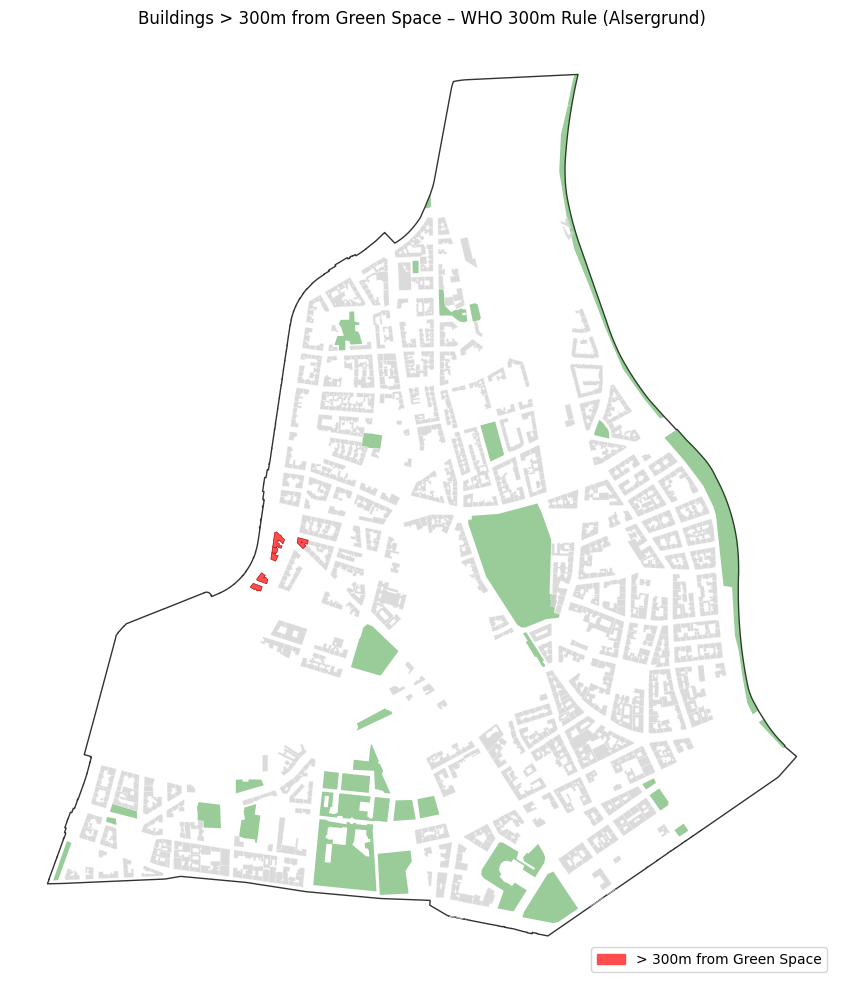


 Processing District: Landstraße
Total buildings: 2482
Within 300m: 2474
Compliant: 99.68%


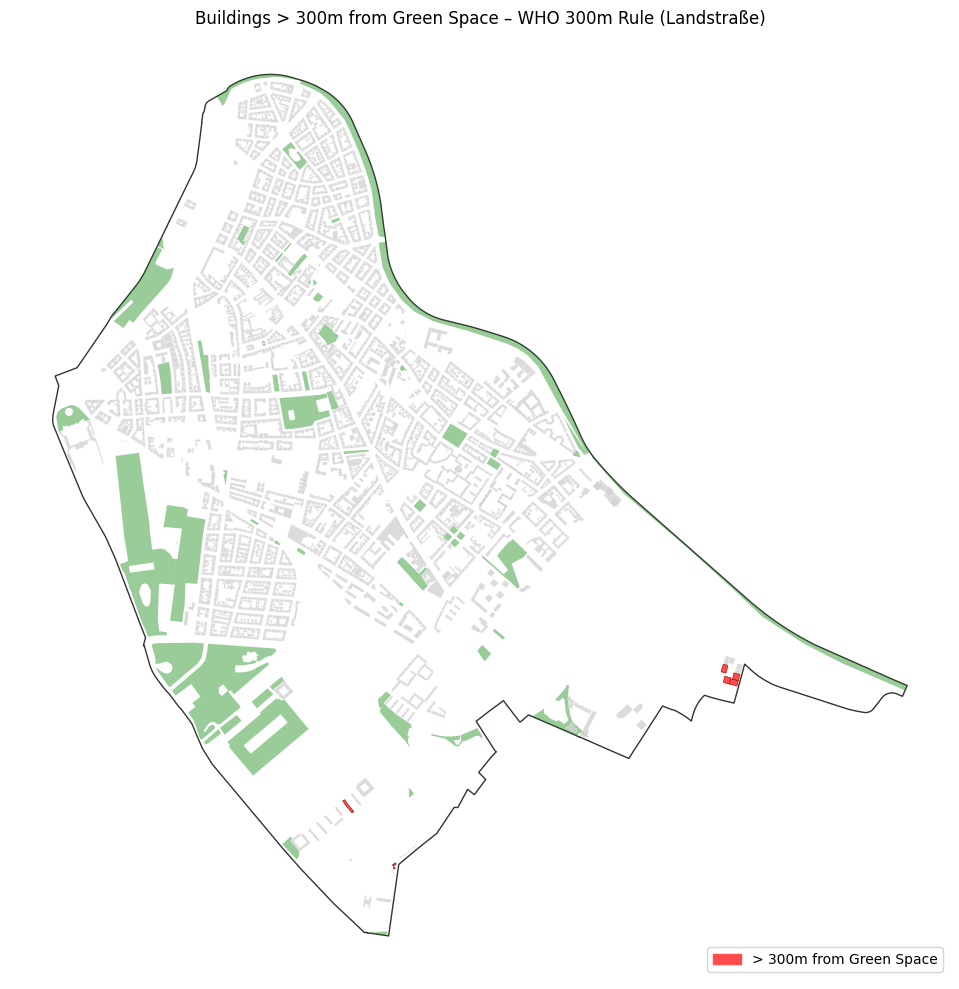


 Processing District: Brigittenau
Total buildings: 1326
Within 300m: 1318
Compliant: 99.40%


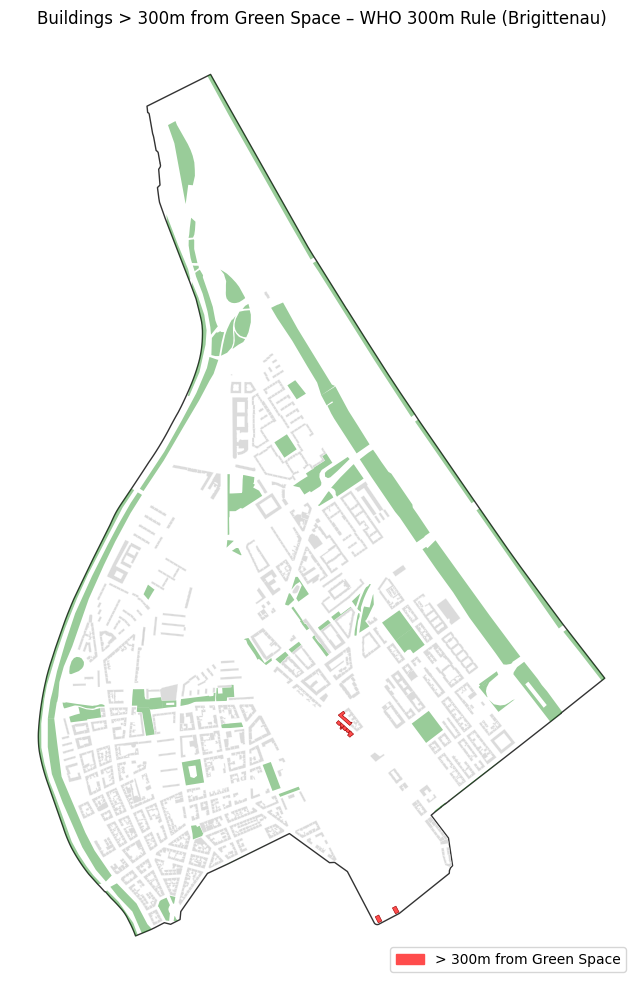


 Processing District: Hernals
Total buildings: 1889
Within 300m: 1749
Compliant: 92.59%


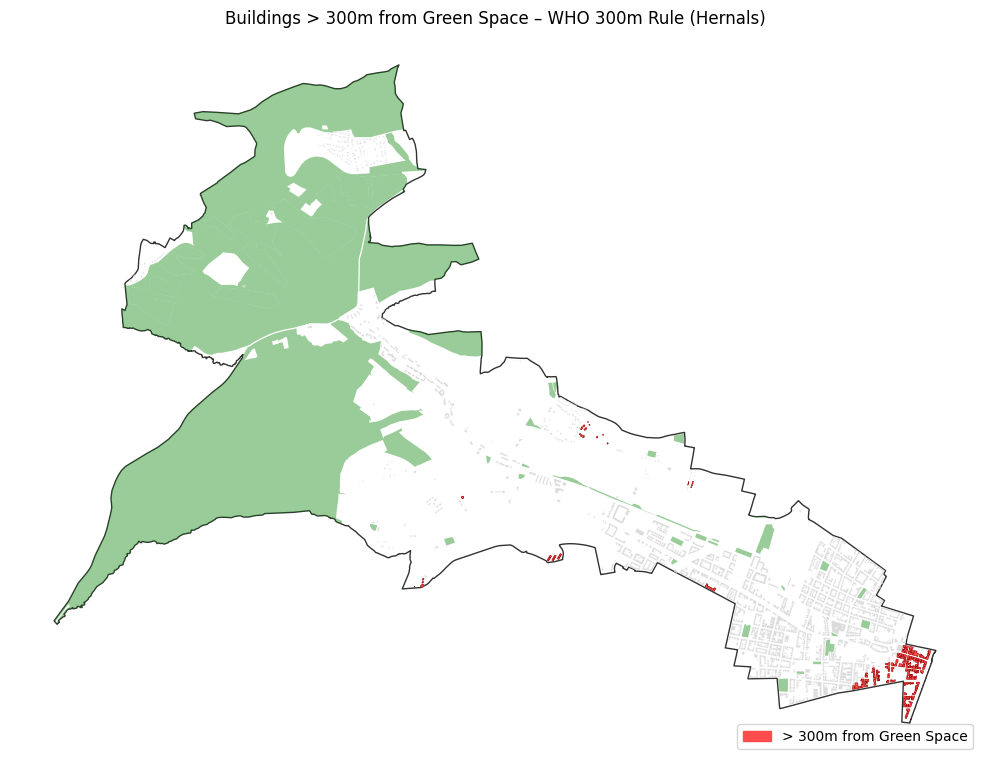


 Processing District: Döbling
Total buildings: 2409
Within 300m: 2347
Compliant: 97.43%


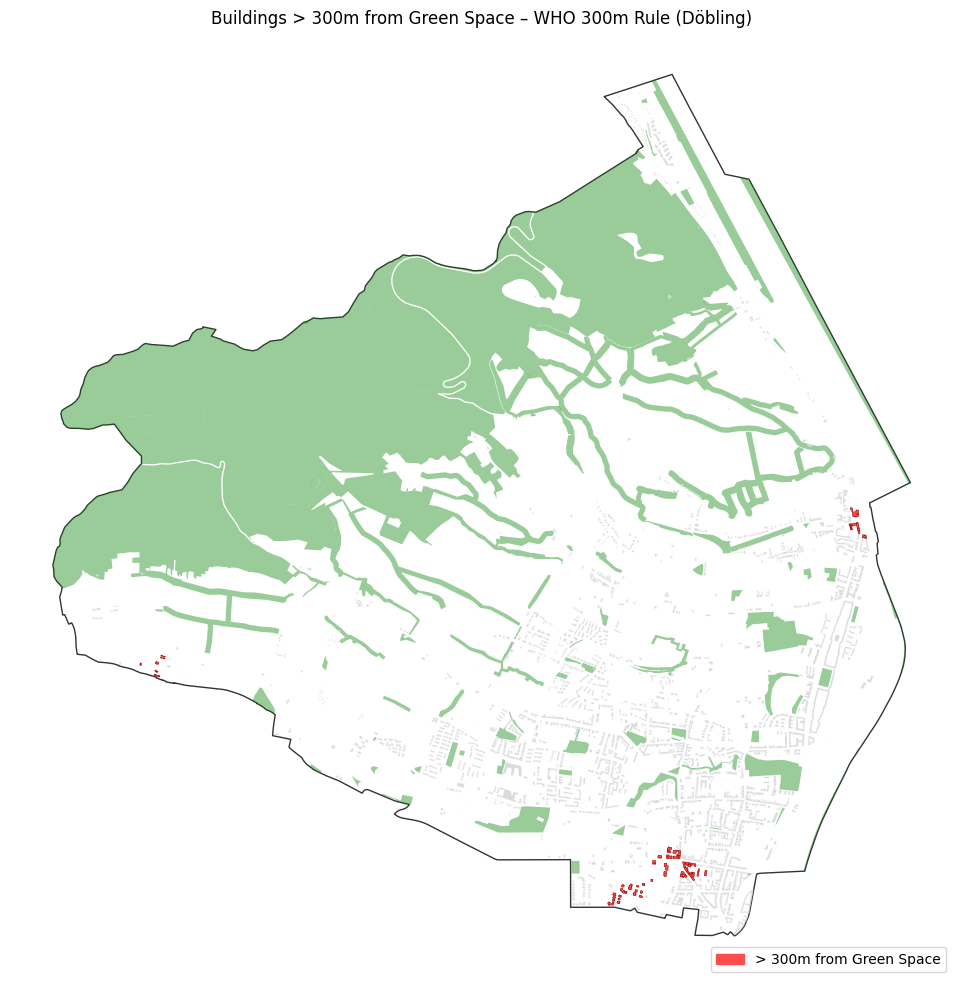


 Processing District: Neubau
Total buildings: 1126
Within 300m: 1109
Compliant: 98.49%


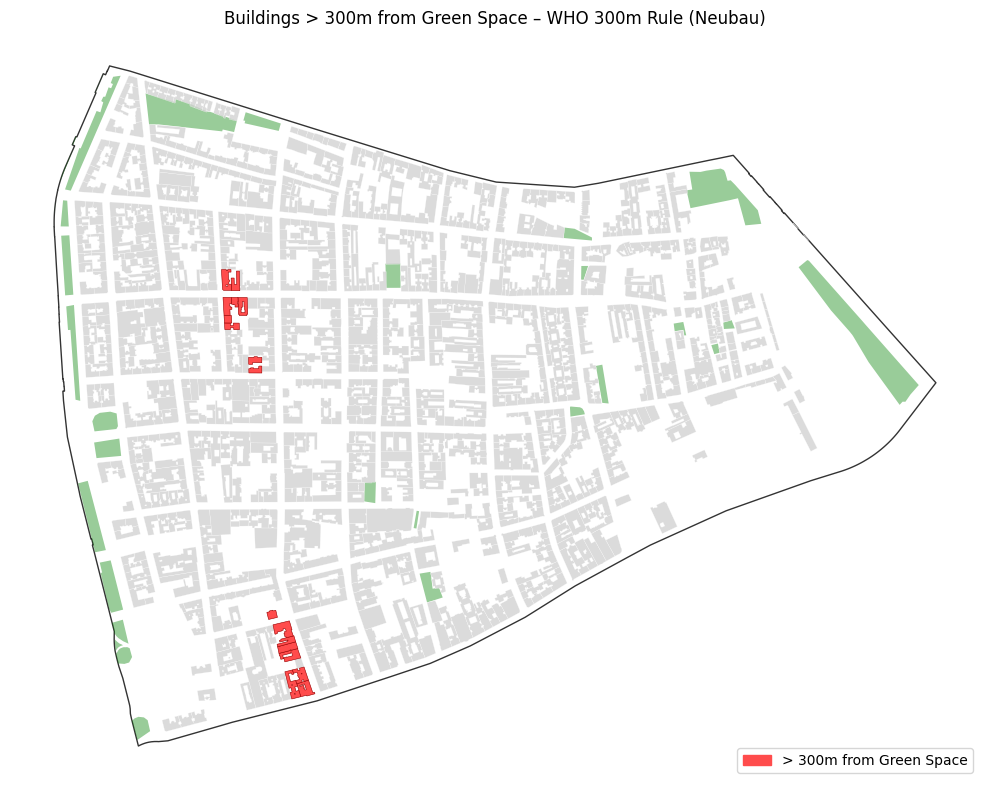


 Processing District: Wieden
Total buildings: 959
Within 300m: 927
Compliant: 96.66%


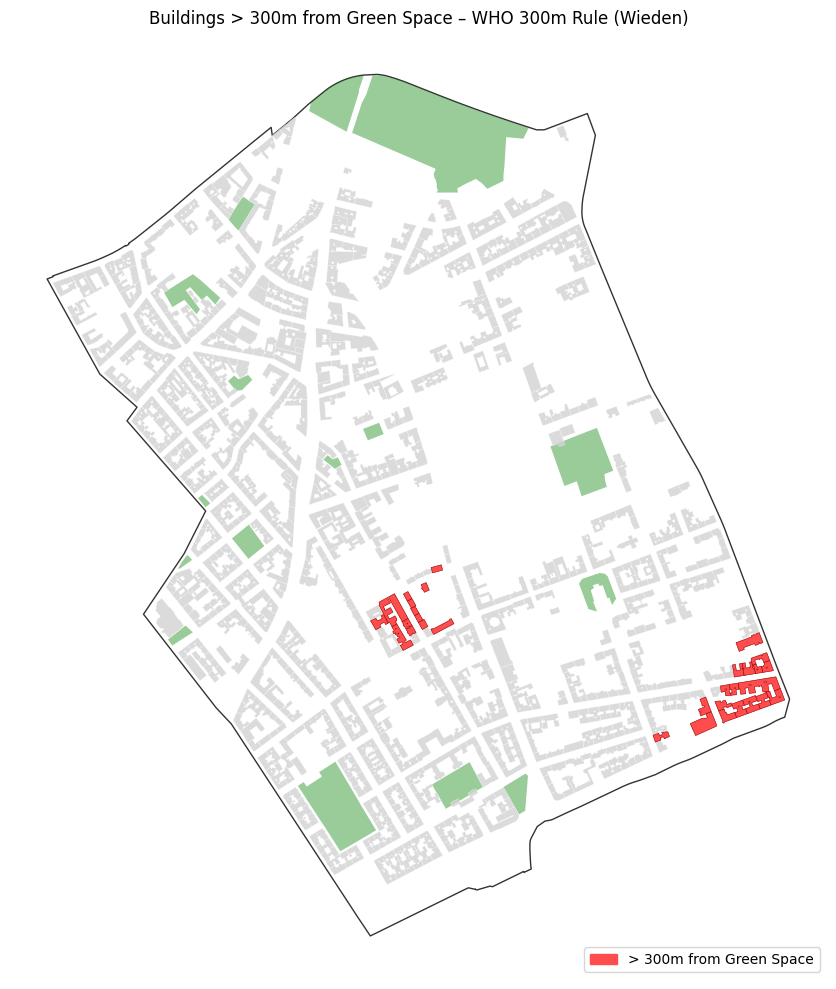


 Processing District: Josefstadt
Total buildings: 691
Within 300m: 616
Compliant: 89.15%


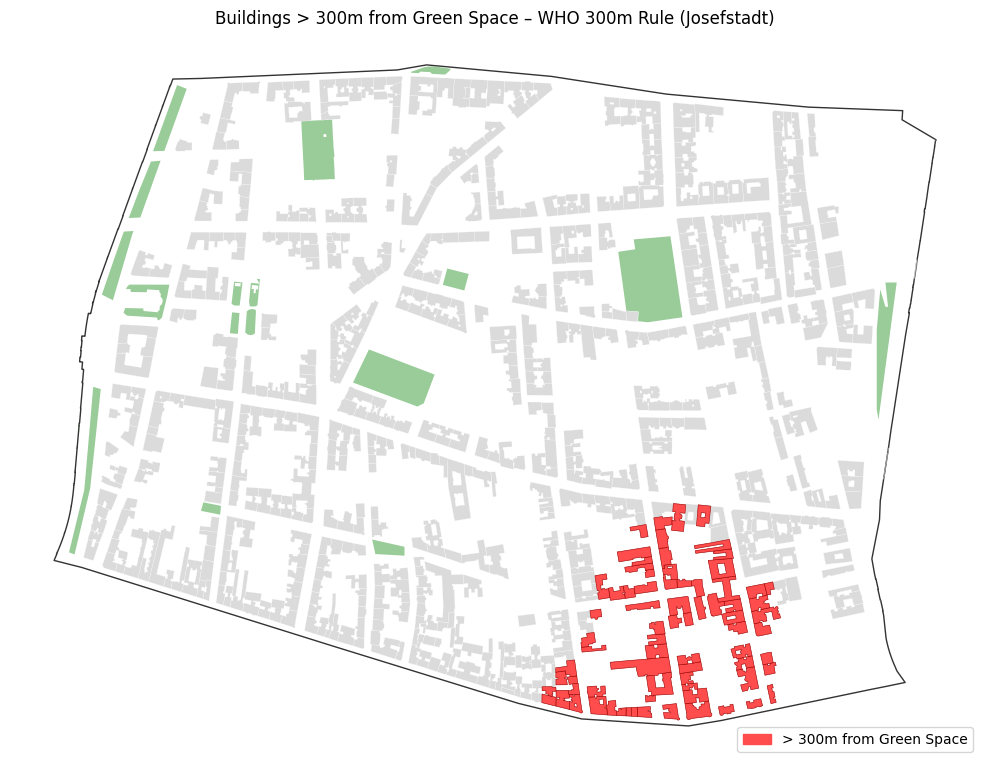


 Processing District: Simmering
Total buildings: 1768
Within 300m: 1723
Compliant: 97.45%


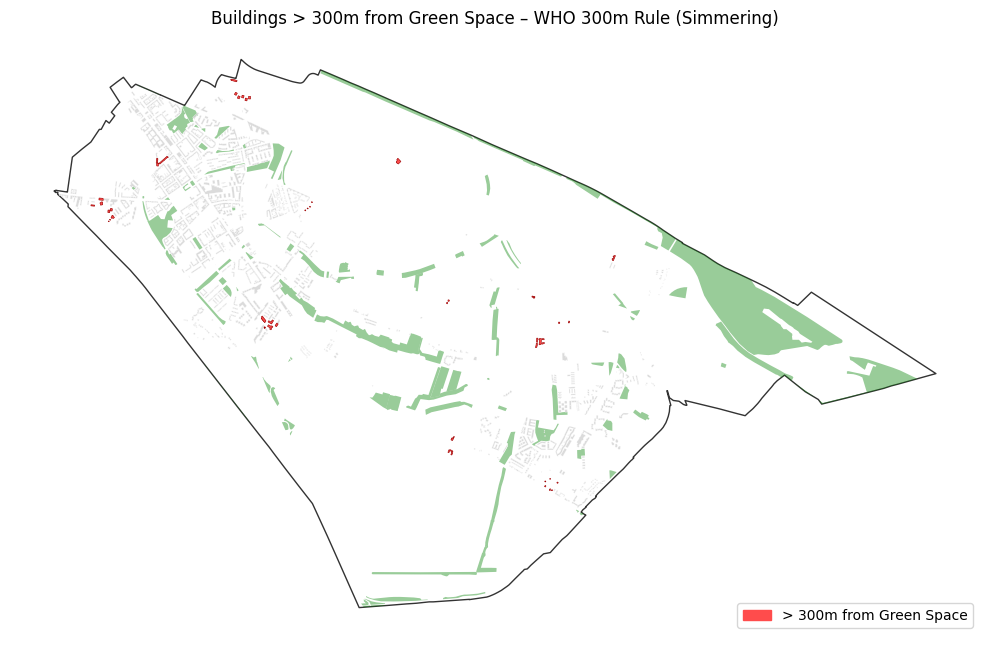


 Processing District: Ottakring
Total buildings: 2703
Within 300m: 2445
Compliant: 90.46%


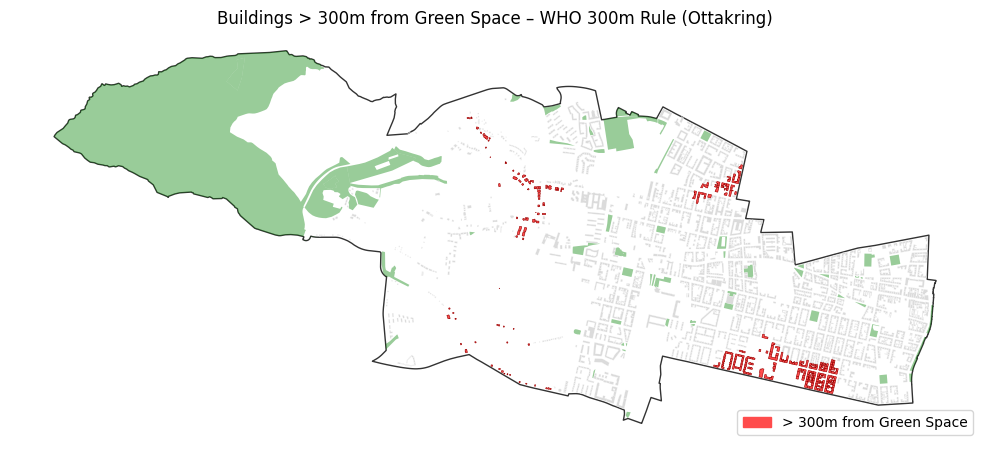


 Processing District: Favoriten
Total buildings: 6051
Within 300m: 5738
Compliant: 94.83%


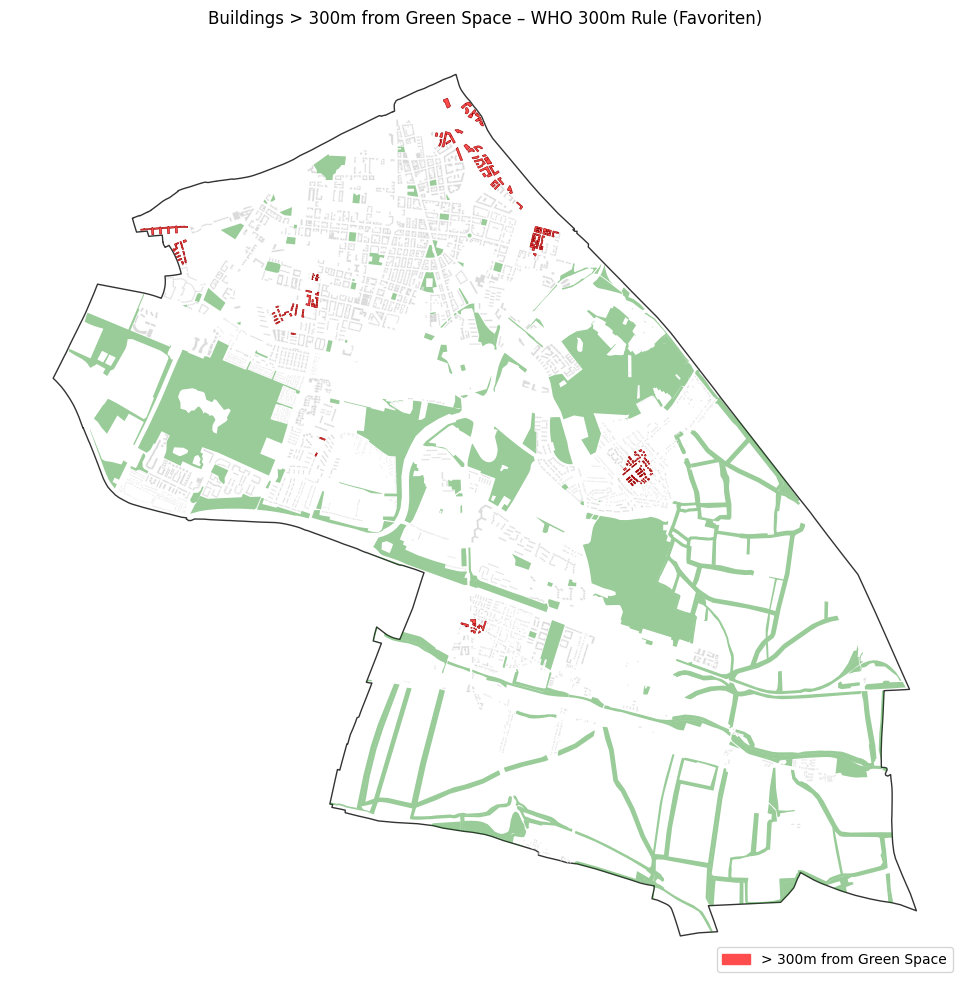


 Processing District: Floridsdorf
Total buildings: 6466
Within 300m: 6036
Compliant: 93.35%


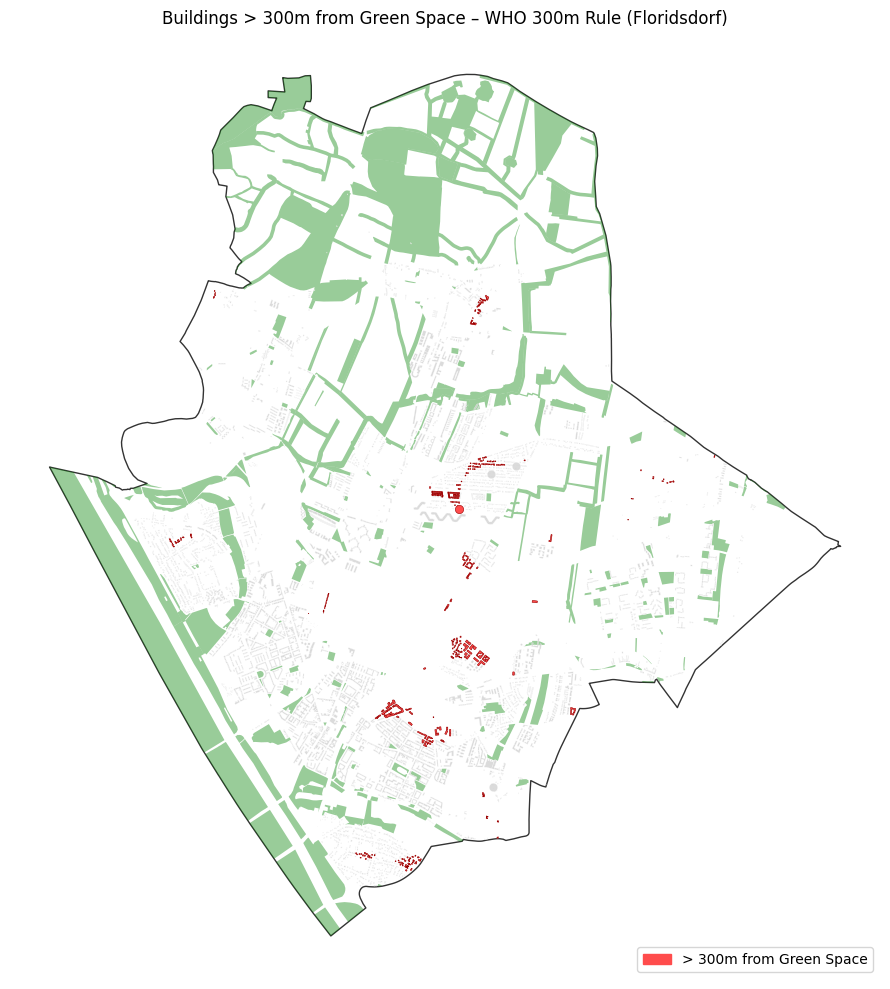


 Processing District: Meidling
Total buildings: 3565
Within 300m: 3198
Compliant: 89.71%


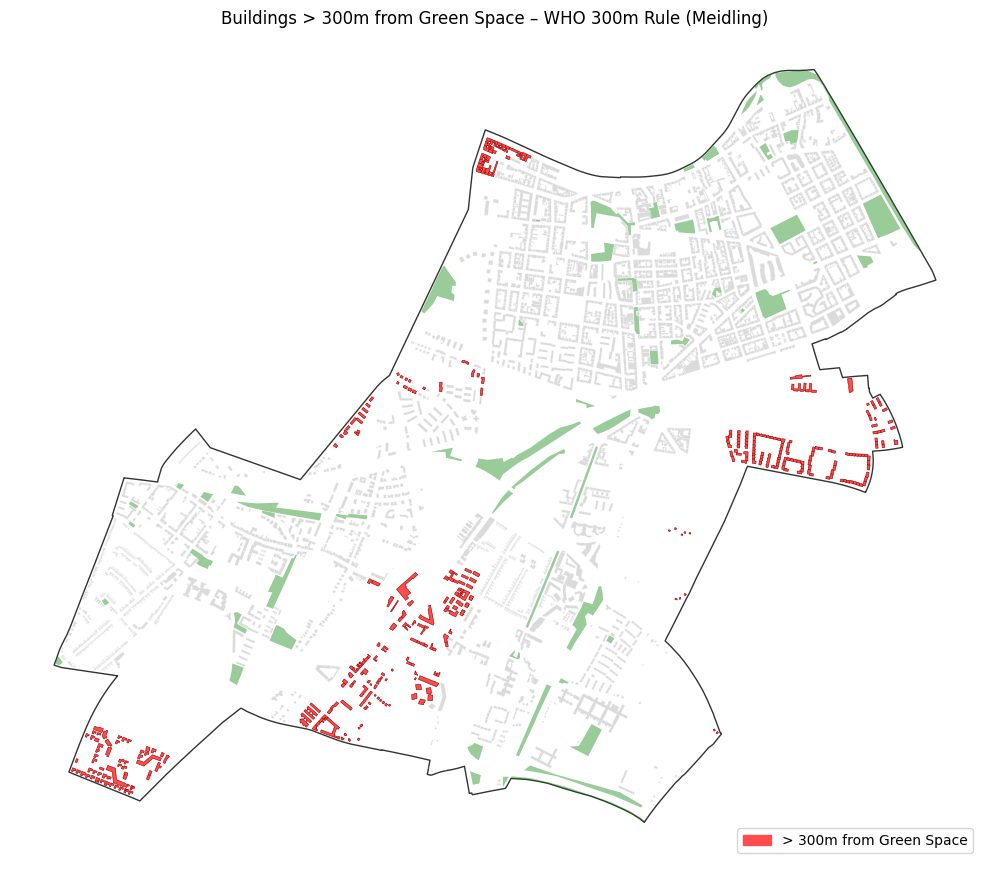


 Processing District: Währing
Total buildings: 1787
Within 300m: 1630
Compliant: 91.21%


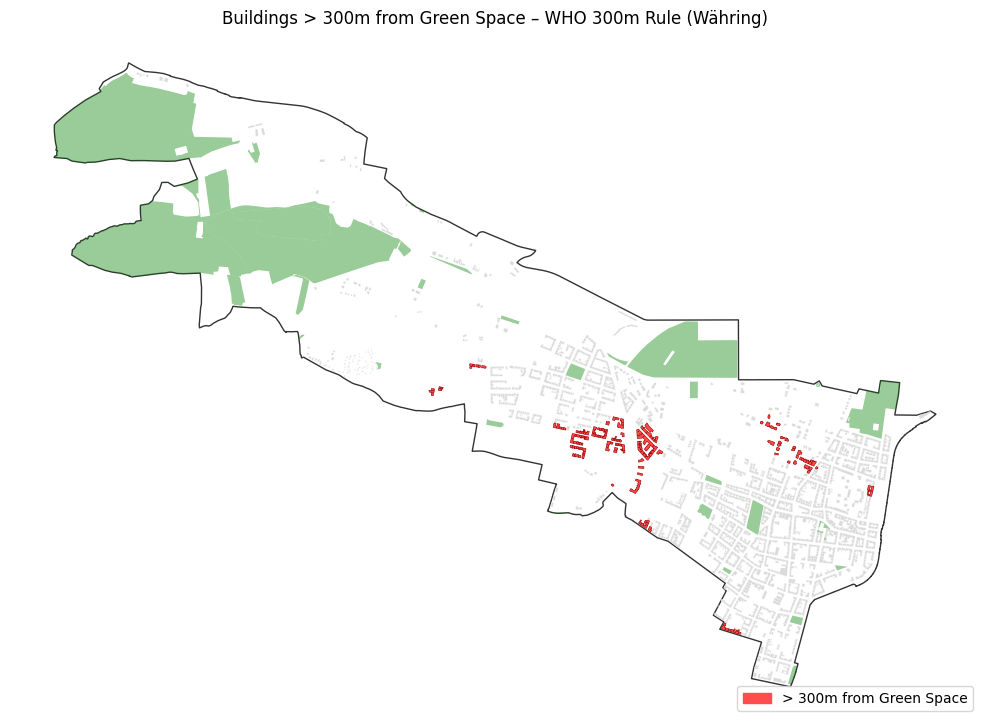


 Processing District: Donaustadt
Total buildings: 11015
Within 300m: 10131
Compliant: 91.97%


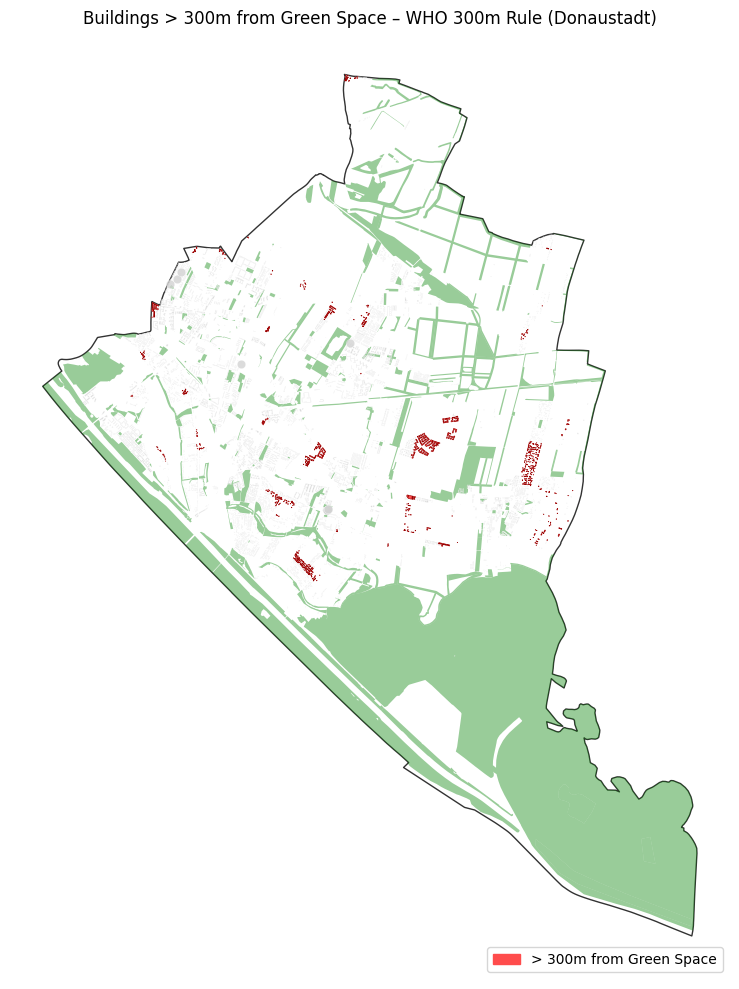


 Processing District: Hietzing
Total buildings: 3079
Within 300m: 2838
Compliant: 92.17%


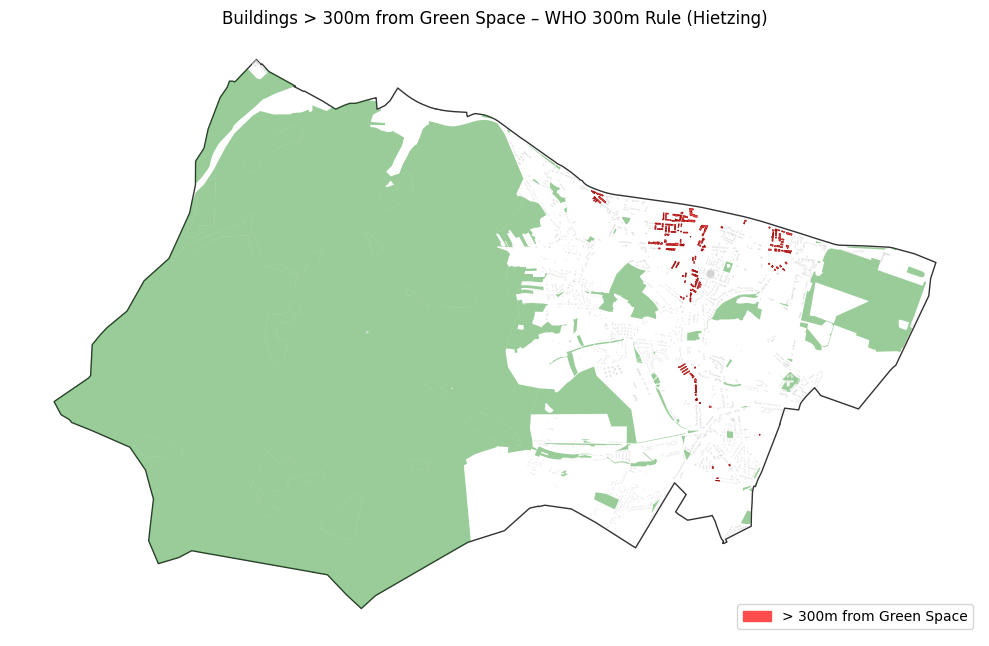


 Processing District: Penzing
Total buildings: 2210
Within 300m: 1997
Compliant: 90.36%


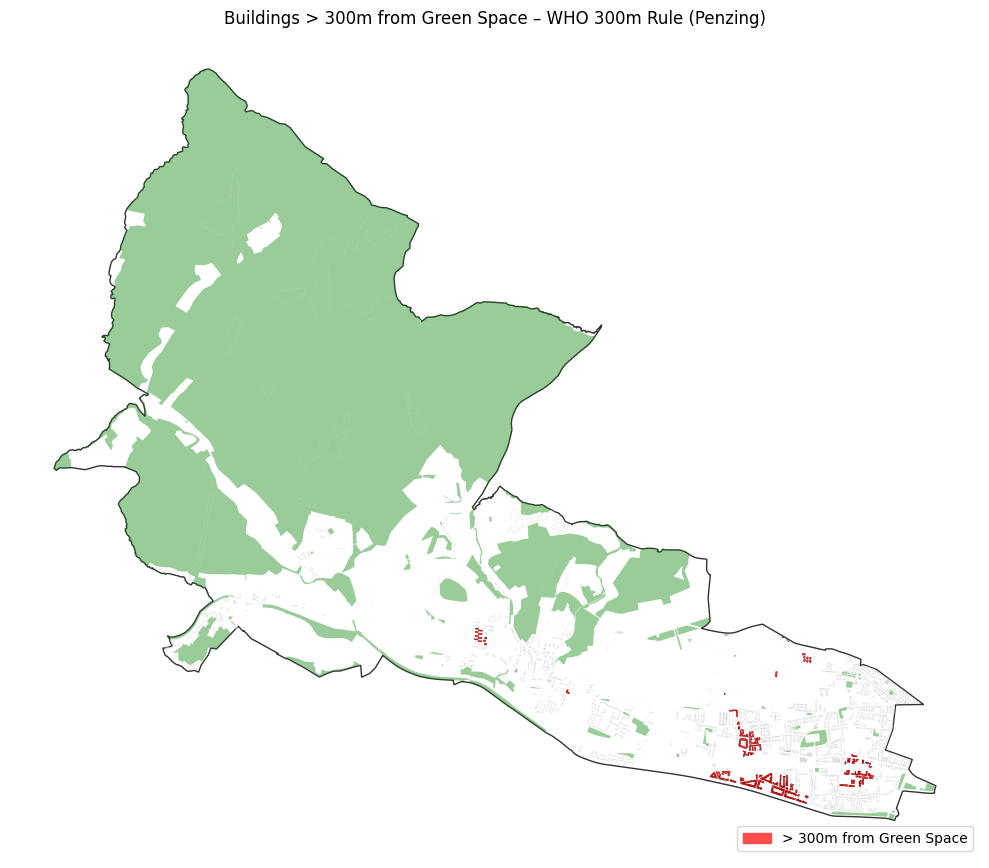


 Processing District: Liesing
Total buildings: 8045
Within 300m: 6714
Compliant: 83.46%


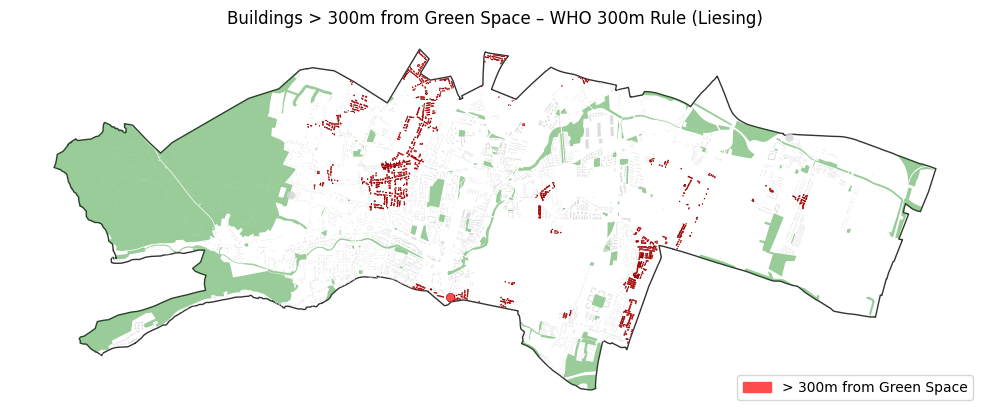


 Processing District: Innere Stadt
Total buildings: 749
Within 300m: 618
Compliant: 82.51%


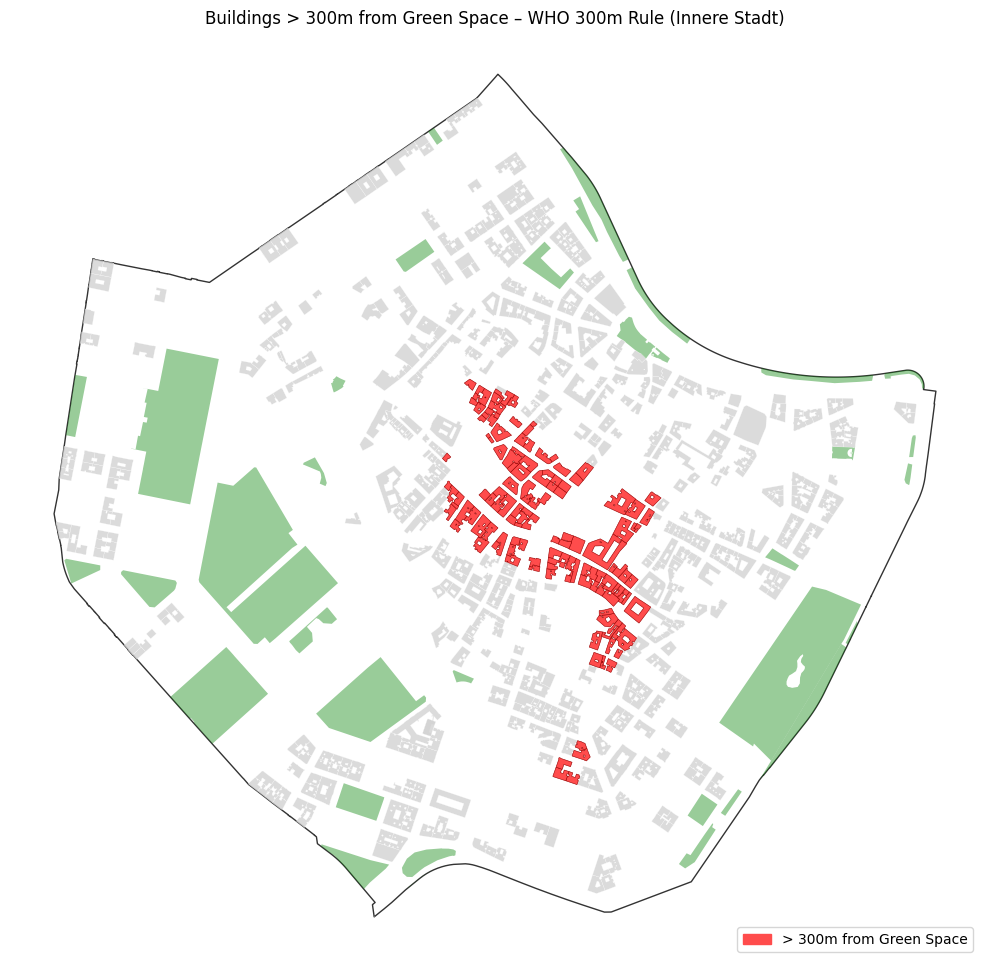

In [50]:
for num, name in target_districts.items():
    print(f"\n Processing District: {name}")

    # Filter district geometry
    district = districts[districts['NAMEK'] == name]
    if district.empty:
        print(f"District '{name}' not found.")
        continue

    # Align CRS
    residential = residential.to_crs(district.crs)
    green = gdf_green.to_crs(district.crs)

    # Clip buildings and green areas to the district
    residential_clipped = gpd.clip(residential, district)
    green_clipped = gpd.clip(green, district)

    # Reproject everything to EPSG:31256
    crs_proj = 31256
    residential_proj = residential_clipped.to_crs(epsg=crs_proj)
    green_proj = green_clipped.to_crs(epsg=crs_proj)
    district_proj = district.to_crs(epsg=crs_proj)

    # Calculate centroids
    res_centroids = residential_proj.copy()
    res_centroids['geometry'] = res_centroids.centroid

    # Create unified green geometry
    green_union = unary_union(green_proj.geometry)

    # Distance calculation
    res_centroids['distance_to_green'] = res_centroids.geometry.apply(lambda x: x.distance(green_union))
    res_centroids['within_300m'] = res_centroids['distance_to_green'] <= 300

    # Basic stats
    total = len(res_centroids)
    within = res_centroids['within_300m'].sum()
    percent = (within / total) * 100 if total > 0 else 0

    print(f"Total buildings: {total}")
    print(f"Within 300m: {within}")
    print(f"Compliant: {percent:.2f}%")

    # Identify non-compliant buildings
    non_compliant_buildings = residential_proj[~res_centroids['within_300m'].values]

    # Plot and Save
    fig, ax = plt.subplots(figsize=(10, 10))
    district_proj.plot(ax=ax, color='none', edgecolor='#333333')  # Outline
    green_proj.plot(ax=ax, color='green', alpha=0.4)  # Green spaces
    residential_proj.plot(ax=ax, color='#D3D3D3', alpha=0.8, edgecolor='white', linewidth=0.2)  # All buildings
    non_compliant_buildings.plot(ax=ax, color='#FF4C4C', edgecolor='#990000', linewidth=0.4)  # Non-compliant

    # Custom legend fix
    import matplotlib.patches as mpatches
    red_patch = mpatches.Patch(color='#FF4C4C', label='> 300m from Green Space')
    plt.legend(handles=[red_patch], loc='lower right')

    # Final touches
    plt.title(f"Buildings > 300m from Green Space – WHO 300m Rule ({name})", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    filename = f"output/who_noncompliant_{name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

